## Load and apply inference models
This notebook loads trained inference models from the outputs of `cmass.infer.train`, plots their prediction performance, and applies them to new test data.

In [100]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

from tools import torch_device

device = torch_device()

# Suppress warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CUDA is not available. Using CPU.


## Load a model

In [ ]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'

cosmonames = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']
hodnames = [r'$\alpha$', r'$\log M_0$', r'$\log M_1$',
            r'$\log M_{\min}$', r'$\sigma_{\log M}$']
noisenames = [r'$\sigma_{\rm radial}$', r'$\sigma_{\rm tangential}$',]
names = cosmonames + noisenames  # +hodnames

# Specify model configuration
nbody = 'quijotelike'
sim = 'fastpm_varnoise'
save_dir = join(wdir, nbody, sim, 'models')

# Specify data dtype
# tracer = 'halo'
tracer = 'simbig_lightcone'
# summaries = ['nbar', 'zPk0']  # , 'zPk2', 'zPk4',  'zQk0']
summaries = ['nbar', 'Pk0', 'Pk2', 'Pk4']  # , 'Qk0']
summary = '+'.join(summaries)
kmin, kmax = 0.0, 0.4
modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')
print(
    f'Loading model: nbody={nbody}, sim={sim}, tracer={tracer}, \n\tsummary={summary}, kmin={kmin}, kmax={kmax}')
print('\n'.join(os.listdir(modelpath)))

Loading model: nbody=quijotelike, sim=fastpm_varnoise, tracer=simbig_lightcone, 
	summary=nbar+Pk0+Pk2+Pk4, kmin=0.0, kmax=0.4
x_val.npy
posterior.pkl
true_logprobs.npy
ids_test.npy
plot_hyperparam_dependence.jpg
theta_train.npy
hodprior.csv
plot_coverage.jpg
theta_test.npy
x_test.npy
nets
plot_true_logprobs.jpg
ids_train.npy
theta_val.npy
ranks_histogram.jpg
plot_single_posterior.jpg
x_train.npy
plot_TARP.jpg
optuna_study.db
plot_predictions.jpg
ids_val.npy
posterior_samples.npy


In [102]:
# Load predictions
xtest = np.load(join(modelpath, 'x_test.npy'))
ytest = np.load(join(modelpath, 'theta_test.npy'))
samps = np.load(join(modelpath, 'posterior_samples.npy'))
percs = np.percentile(samps, [16, 50, 84], axis=0)

yrange = np.stack([
    ytest.min(axis=0),
    ytest.max(axis=0)
], axis=1)

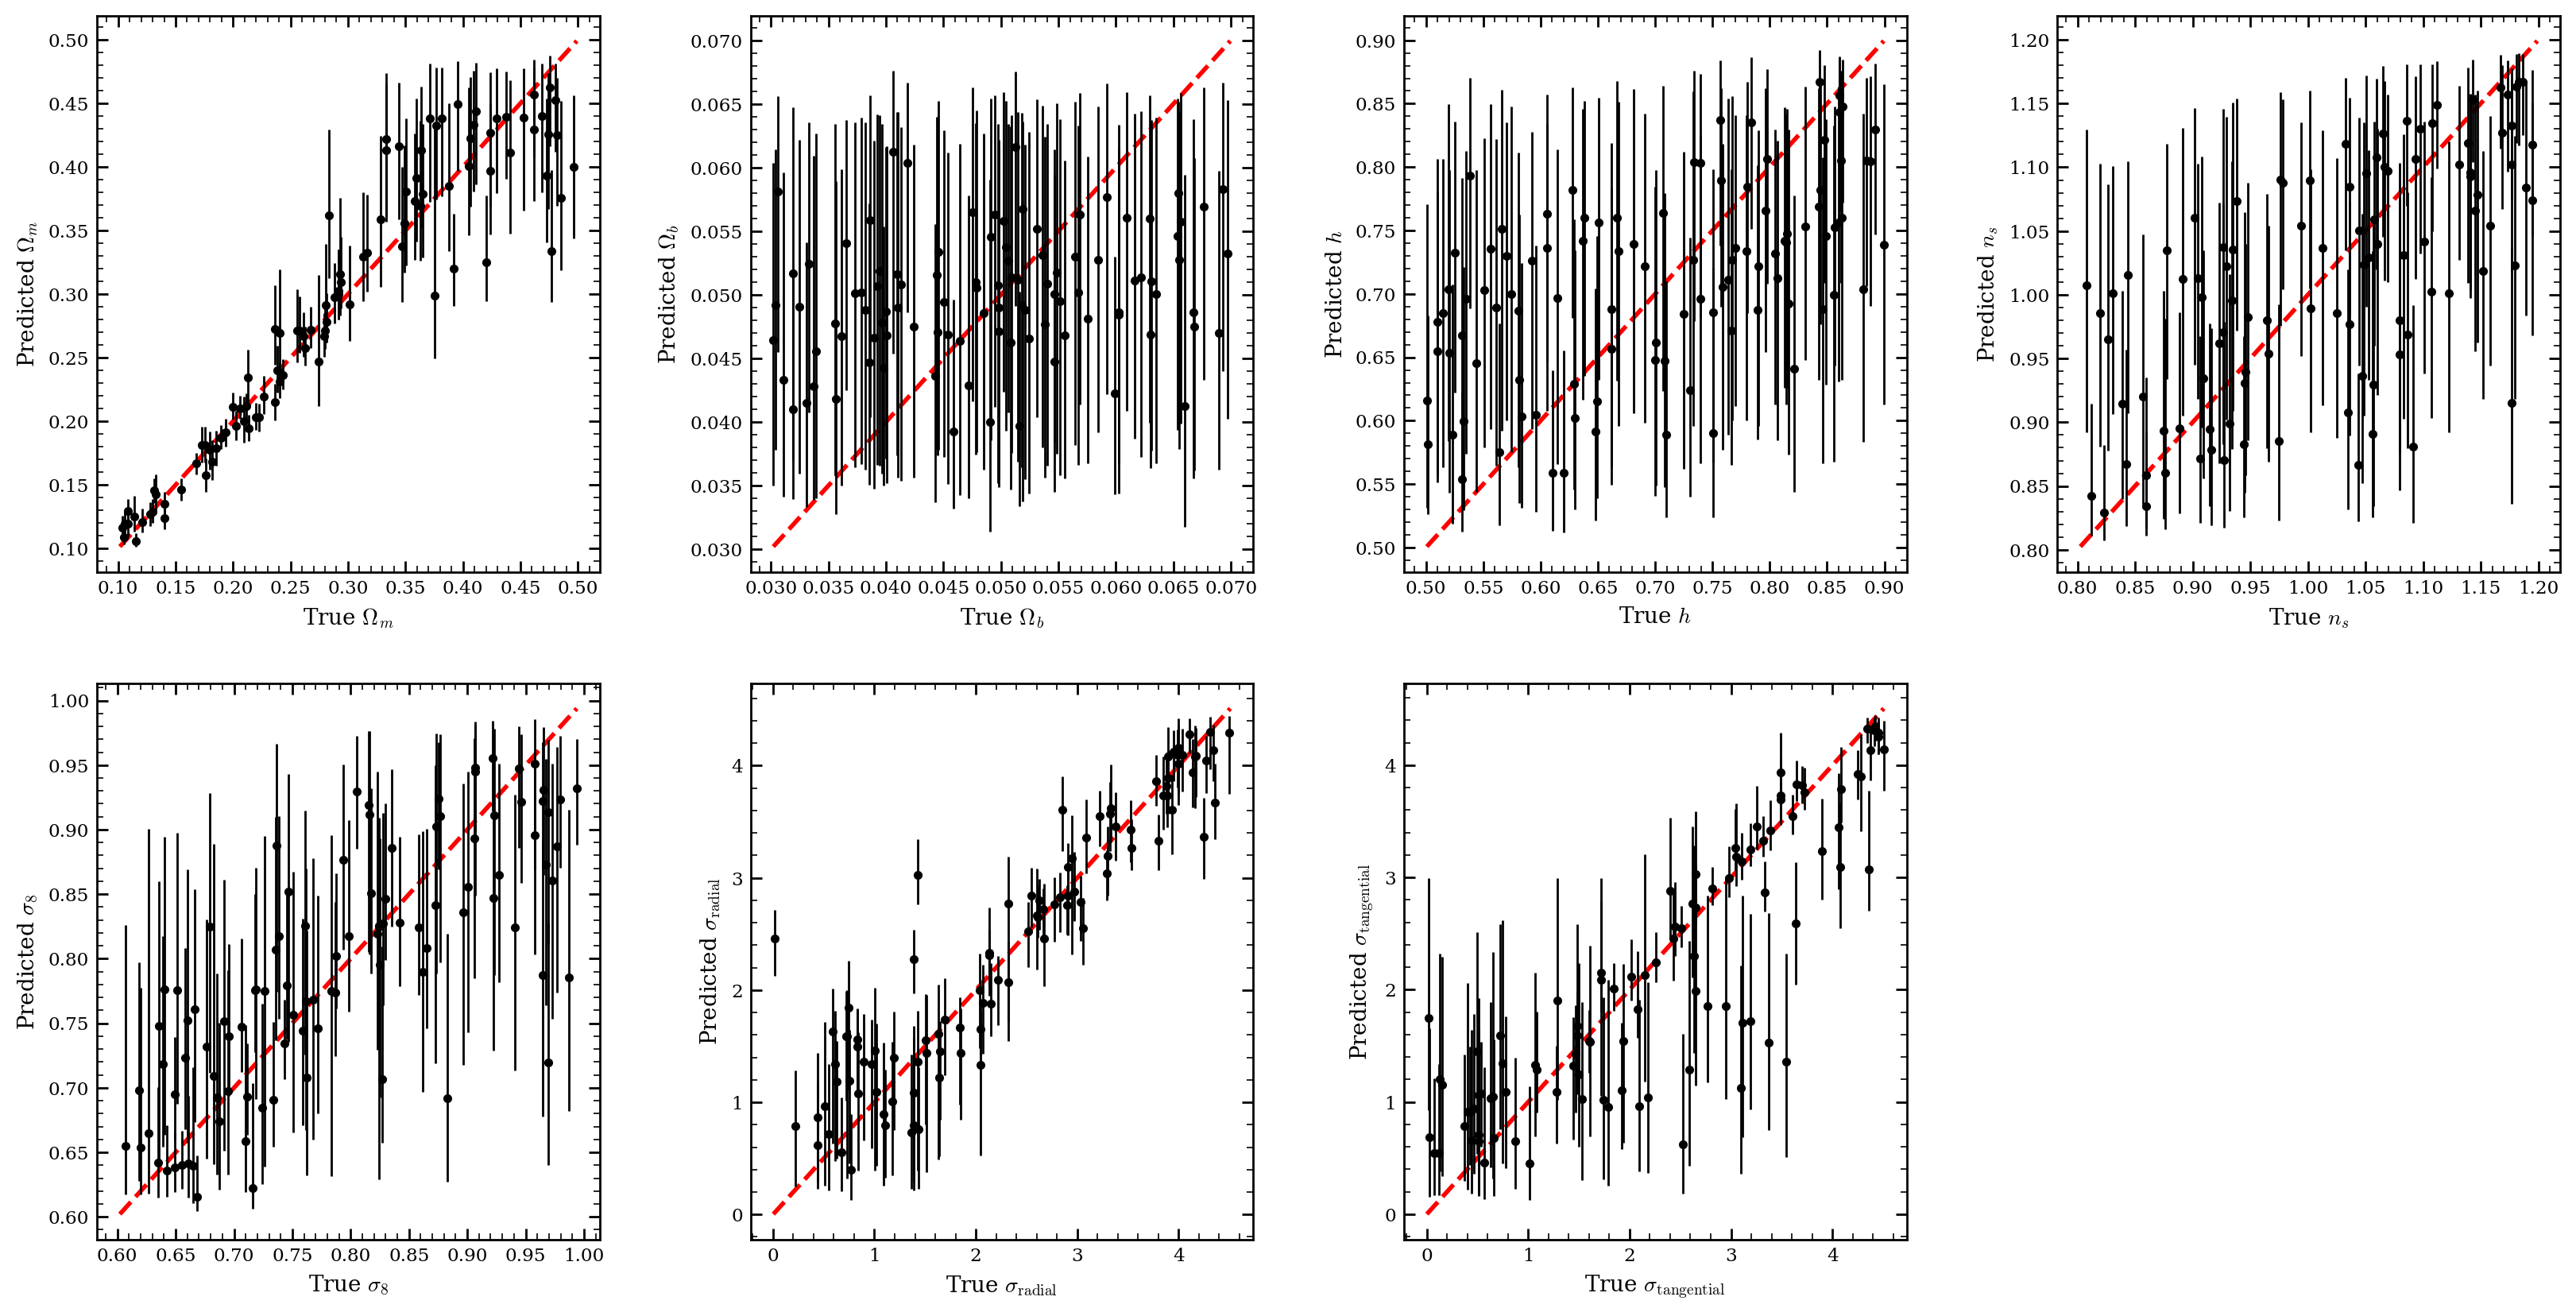

In [103]:
ss = 10

N = len(names)
H, W = N//4 + (N % 4 > 0), 4
f, axs = plt.subplots(H, W, figsize=(5*W, 5*H), gridspec_kw=dict(wspace=0.3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i >= N:
        ax.axis('off')
        continue
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.plot(ytest[::ss, i], percs[1, ::ss, i], 'k.')
    ax.errorbar(ytest[::ss, i], percs[1, ::ss, i], yerr=[percs[1, ::ss, i]-percs[0, ::ss, i],
                percs[2, ::ss, i]-percs[1, ::ss, i]], fmt='none', ecolor='k', elinewidth=1)
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')

In [104]:
# # Load literature data
# lit_path = join(wdir, 'literature', 'processed')

# # SimBIG zPk024
# filename = join(lit_path, 'simbig_pk.csv')
# simpk = pd.read_csv(filename)
# simpk.columns = names
# simpk['Model'] = 'SimBIG zPk024'

# # SimBIG zQk0
# filename = join(lit_path, 'simbig_bk.csv')
# simbk = pd.read_csv(filename)
# simbk.columns = names
# simbk['Model'] = 'SimBIG zQk0'

# # print(simpk.shape, simbk.shape)
# # simbk

In [105]:
# if 'nbar' not in summaries:
#     raise ValueError('Cell only works for nbar summary')

# nbar_CMASS = np.log10(3e-4)
# sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
# sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

# W = 3
# H = len(names) // W + (len(names) % W > 0)

# f, axs = plt.subplots(H, W, figsize=(5*W, 3*H),
#                       sharex=True,
#                       gridspec_kw=dict(hspace=0.1))
# axs = axs.flatten()
# for i, ax in enumerate(axs):
#     if i >= len(names):
#         ax.axis('off')
#         continue
#     ax.plot(xtest[:, -1], samps.std(axis=0)[:, i], '.', alpha=0.5)
#     ax.axvline(nbar_CMASS, color='r', ls='--', label='CMASS')
#     ax.axhline(sb_pkstd[i], color='C2', ls='--', label='SimBIG Pk')
#     ax.axhline(sb_bkstd[i], color='C4', ls='--', label='SimBIG Bk')
#     ax.set_ylabel(f'Posterior STD[{names[i]}]')
#     ax.set_ylim(0)
#     if i == len(names) - 1:
#         ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
#     if i == 0:
#         ax.legend()

# f.suptitle(
#     f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$')

In [106]:
from tools import load_posterior

posterior = load_posterior(modelpath)
for p in posterior.posteriors:
    print(type(p.nde.flow))

<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>


100%|██████████| 19/19 [00:00<00:00, 572.65it/s]


[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Log Probability')]

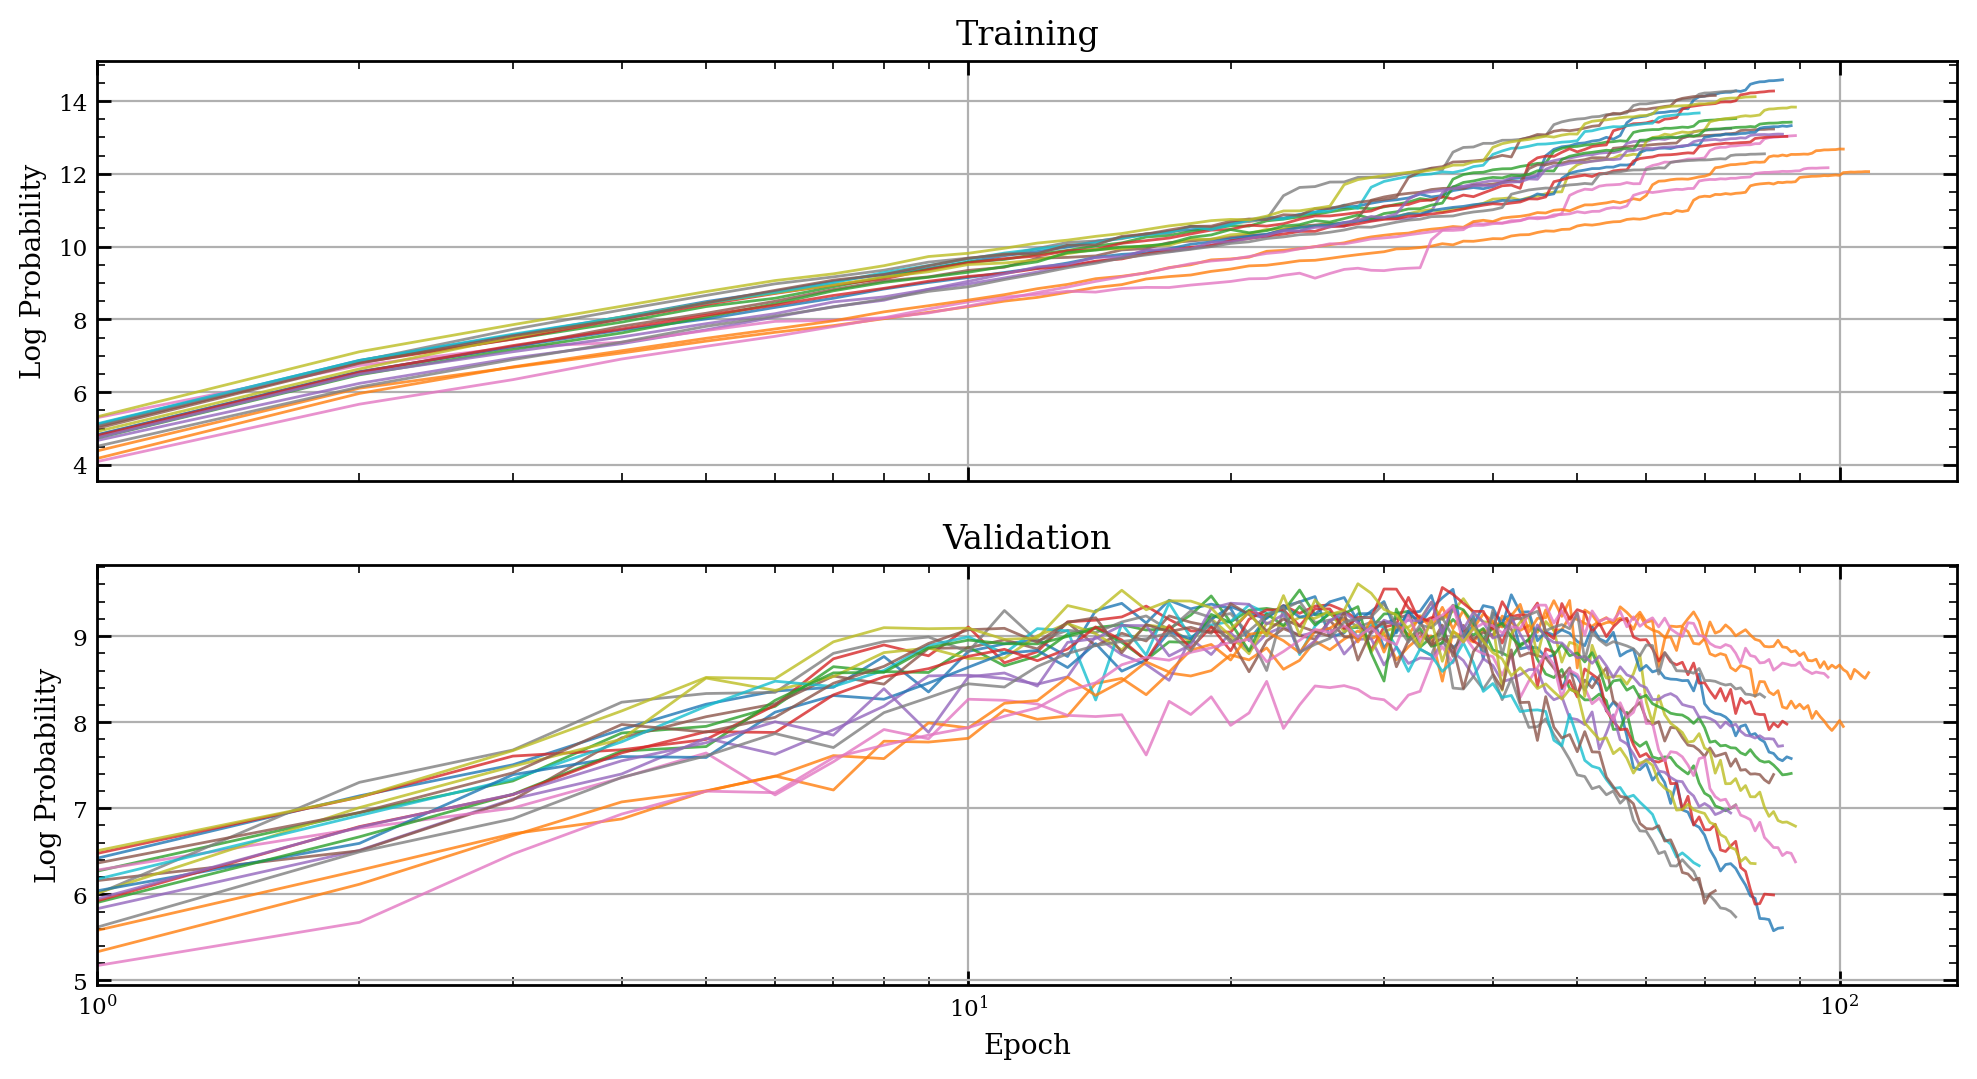

In [107]:
ss = 10

netpath = join(modelpath, 'nets')
netlist = os.listdir(netpath)

f, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for n in tqdm(netlist[::ss]):
    filepath = join(netpath, n, 'summary.json')
    if not os.path.exists(filepath):
        continue
    with open(filepath, 'r') as f:
        history = json.load(f)

    x_ = range(1, len(history[0]['training_log_probs'])+1)

    ax = axs[0]
    ax.plot(x_, history[0]['training_log_probs'], alpha=0.8, lw=1)

    ax = axs[1]
    ax.plot(x_, history[0]['validation_log_probs'], alpha=0.8, lw=1)

ax.semilogx()
ax.set_xlim(1)
# ax.set_ylim(-10, 20)

axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[0].grid()
axs[1].grid()

axs[0].set(ylabel='Log Probability')
axs[1].set(xlabel='Epoch', ylabel='Log Probability')

INFO:root:Sampling models with [210, 206, 203, 203, 200, 199, 198, 196, 196, 194] samples each.
Drawing 210 posterior samples: 404it [00:01, 226.76it/s]                         
Drawing 206 posterior samples: 401it [00:05, 77.31it/s]                         
Drawing 203 posterior samples: 381it [00:02, 129.44it/s]                        
Drawing 203 posterior samples: 398it [00:04, 82.64it/s]                         
Drawing 200 posterior samples: 382it [00:04, 77.73it/s]                         
Drawing 199 posterior samples: 384it [00:02, 175.07it/s]                        
Drawing 198 posterior samples: 383it [00:04, 78.54it/s]                         
Drawing 196 posterior samples: 381it [00:04, 77.88it/s]                         
Drawing 196 posterior samples: 372it [00:04, 75.67it/s]                         
Drawing 194 posterior samples: 381it [00:04, 82.65it/s]                         


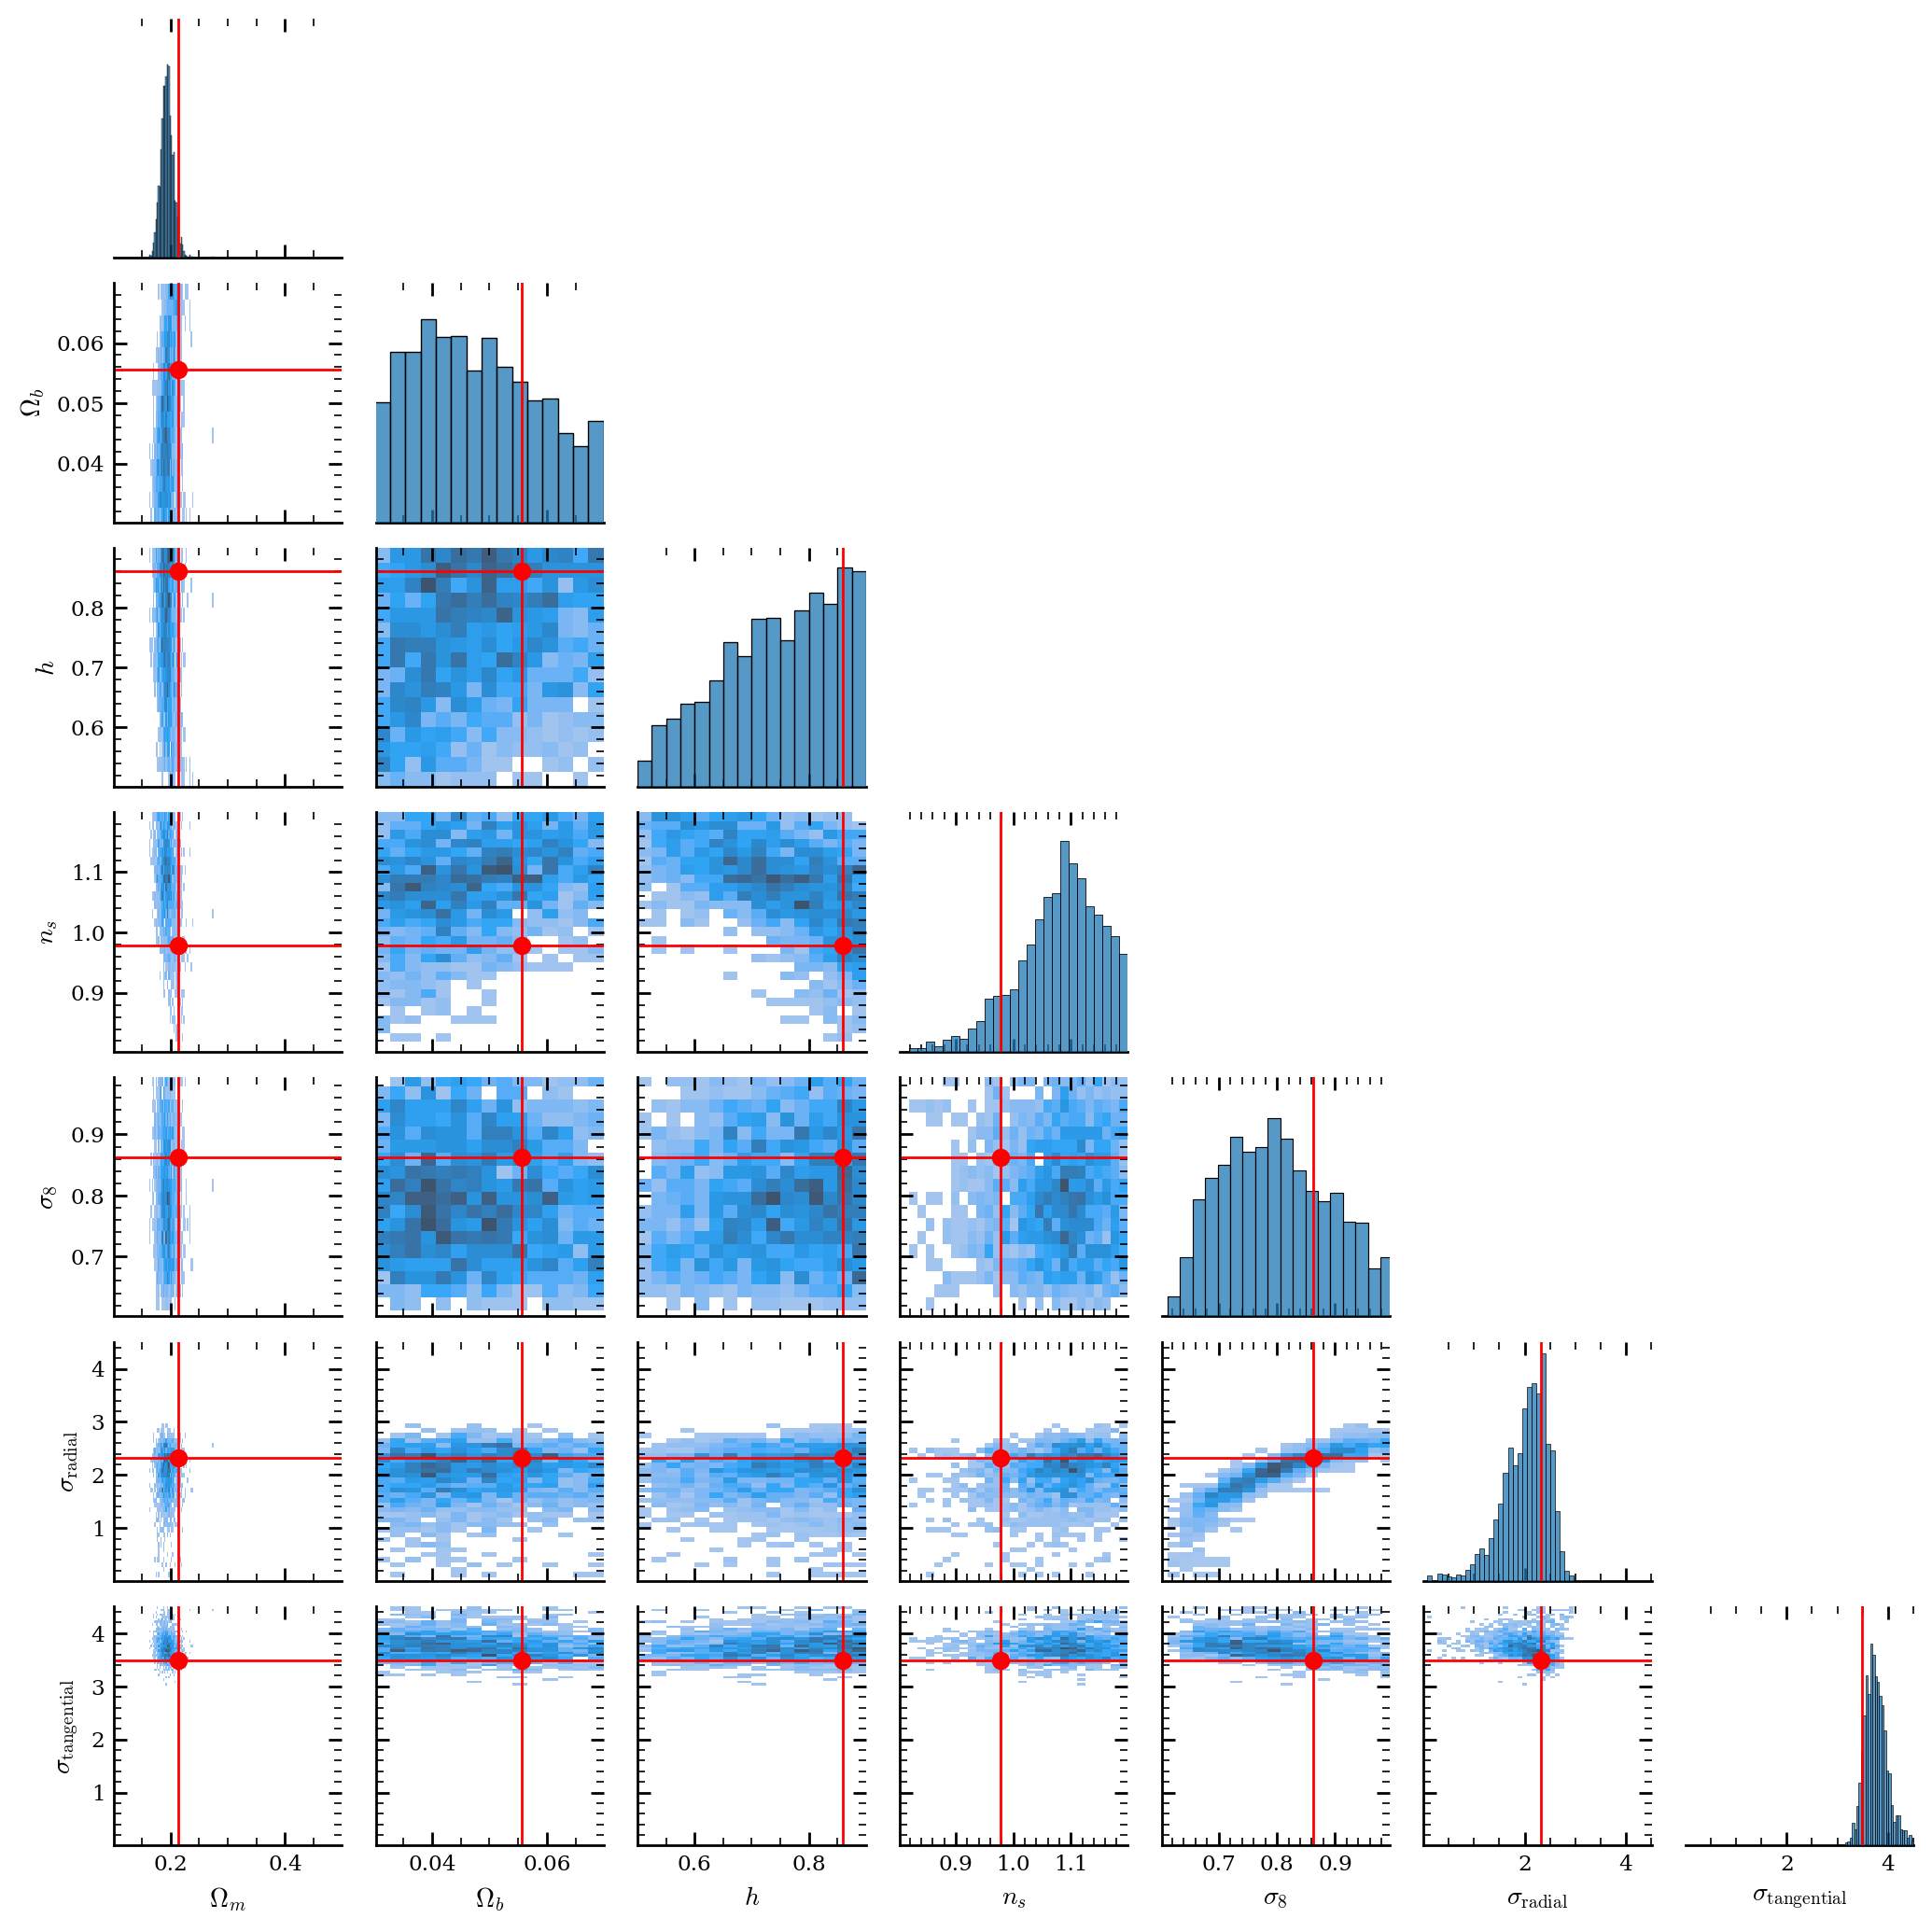

In [108]:
from tools import plot_true_vals, set_boundaries

# Predict on a random test point
ind = 0
x0 = torch.Tensor(xtest[ind]).to(device)
y0 = ytest[ind]
samp0 = posterior.sample(x=x0, shape=(2000,))
samp0 = pd.DataFrame(samp0, columns=names)

g = sns.pairplot(
    samp0,
    vars=names,
    kind='hist',
    corner=True,
    height=1.5
    # plot_kws={'alpha': 0.5, 'levels': [0.05, 0.36, 1], 'fill': True},  # for kde plot
)

plot_true_vals(g, y0, color='r', lw=1)
set_boundaries(g, yrange)

## Load an observed summary

In [119]:
# Load observed data
nbody = 'quijote'
sim = 'varnoise'
save_dir = join(wdir, nbody, sim, 'models')
modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')

xobs = np.load(join(modelpath, 'x_test.npy'))
yobs = np.load(join(modelpath, 'theta_test.npy'))
xid = np.load(join(modelpath, 'ids_test.npy'))

ss = 10
xobs = xobs[::ss]
yobs = yobs[::ss]
xid = xid[::ss]

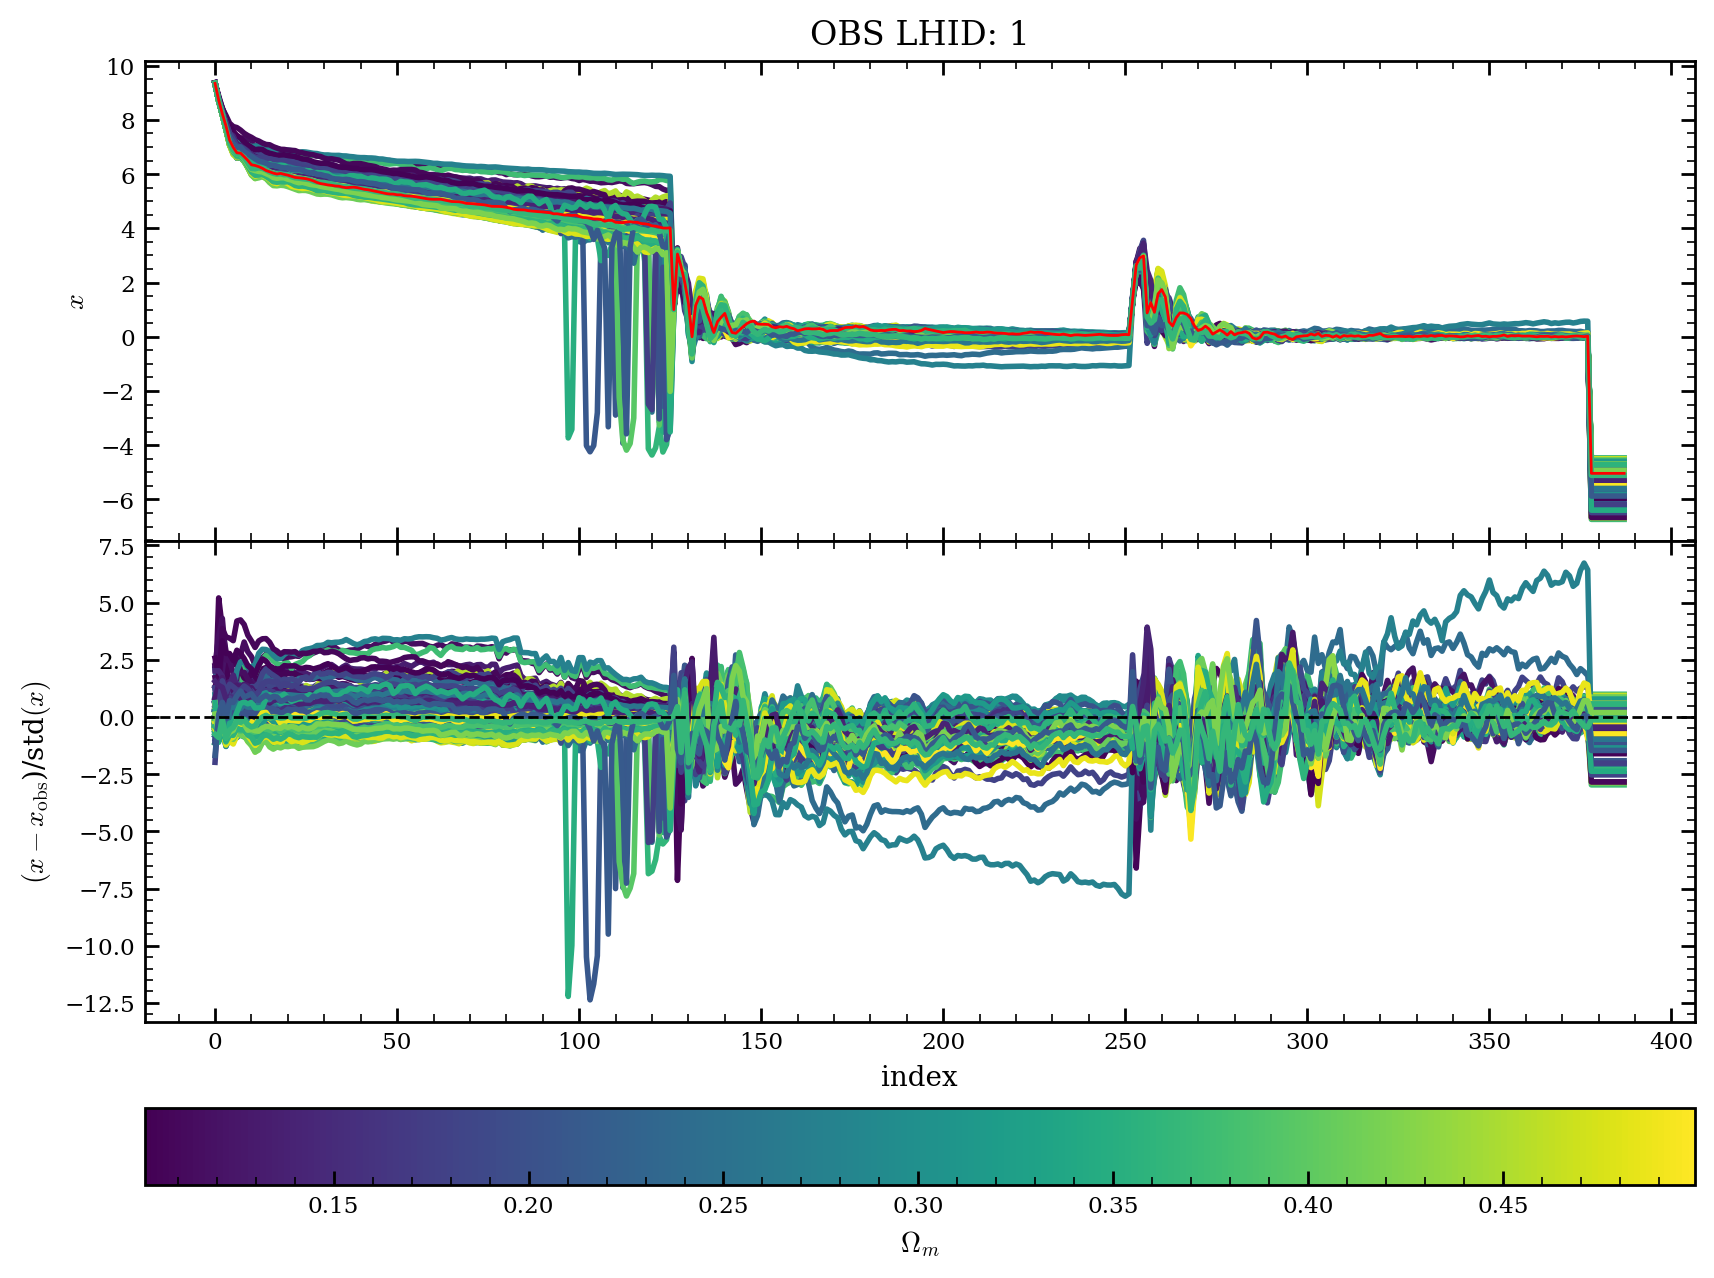

In [120]:
ss = 10
ind = 0

f, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                      gridspec_kw=dict(hspace=0., height_ratios=[1, 1]))

par = ytest[:, 0]
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=par.min(), vmax=par.max())

ax = axs[0]
for i in range(0, len(xtest), ss):
    ax.plot(xtest[i], color=cmap(norm(par[i])))
ax.plot(xobs[ind], 'r-', lw=1)
ax.set(ylabel=r'$x$')
ax.set_title(f'OBS LHID: {xid[ind]}')

ax = axs[1]
for i in range(0, len(xtest), ss):
    ax.plot((xtest[i]-xobs[ind])/np.std(xtest, axis=0),
            color=cmap(norm(par[i])))
ax.axhline(0, c='k', ls='--', lw=1)
ax.set(xlabel='index', ylabel=r'$(x - x_{\rm obs}$)/std$(x)$')

cbar = f.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', pad=0.07)
cbar.set_label(r'$\Omega_m$')

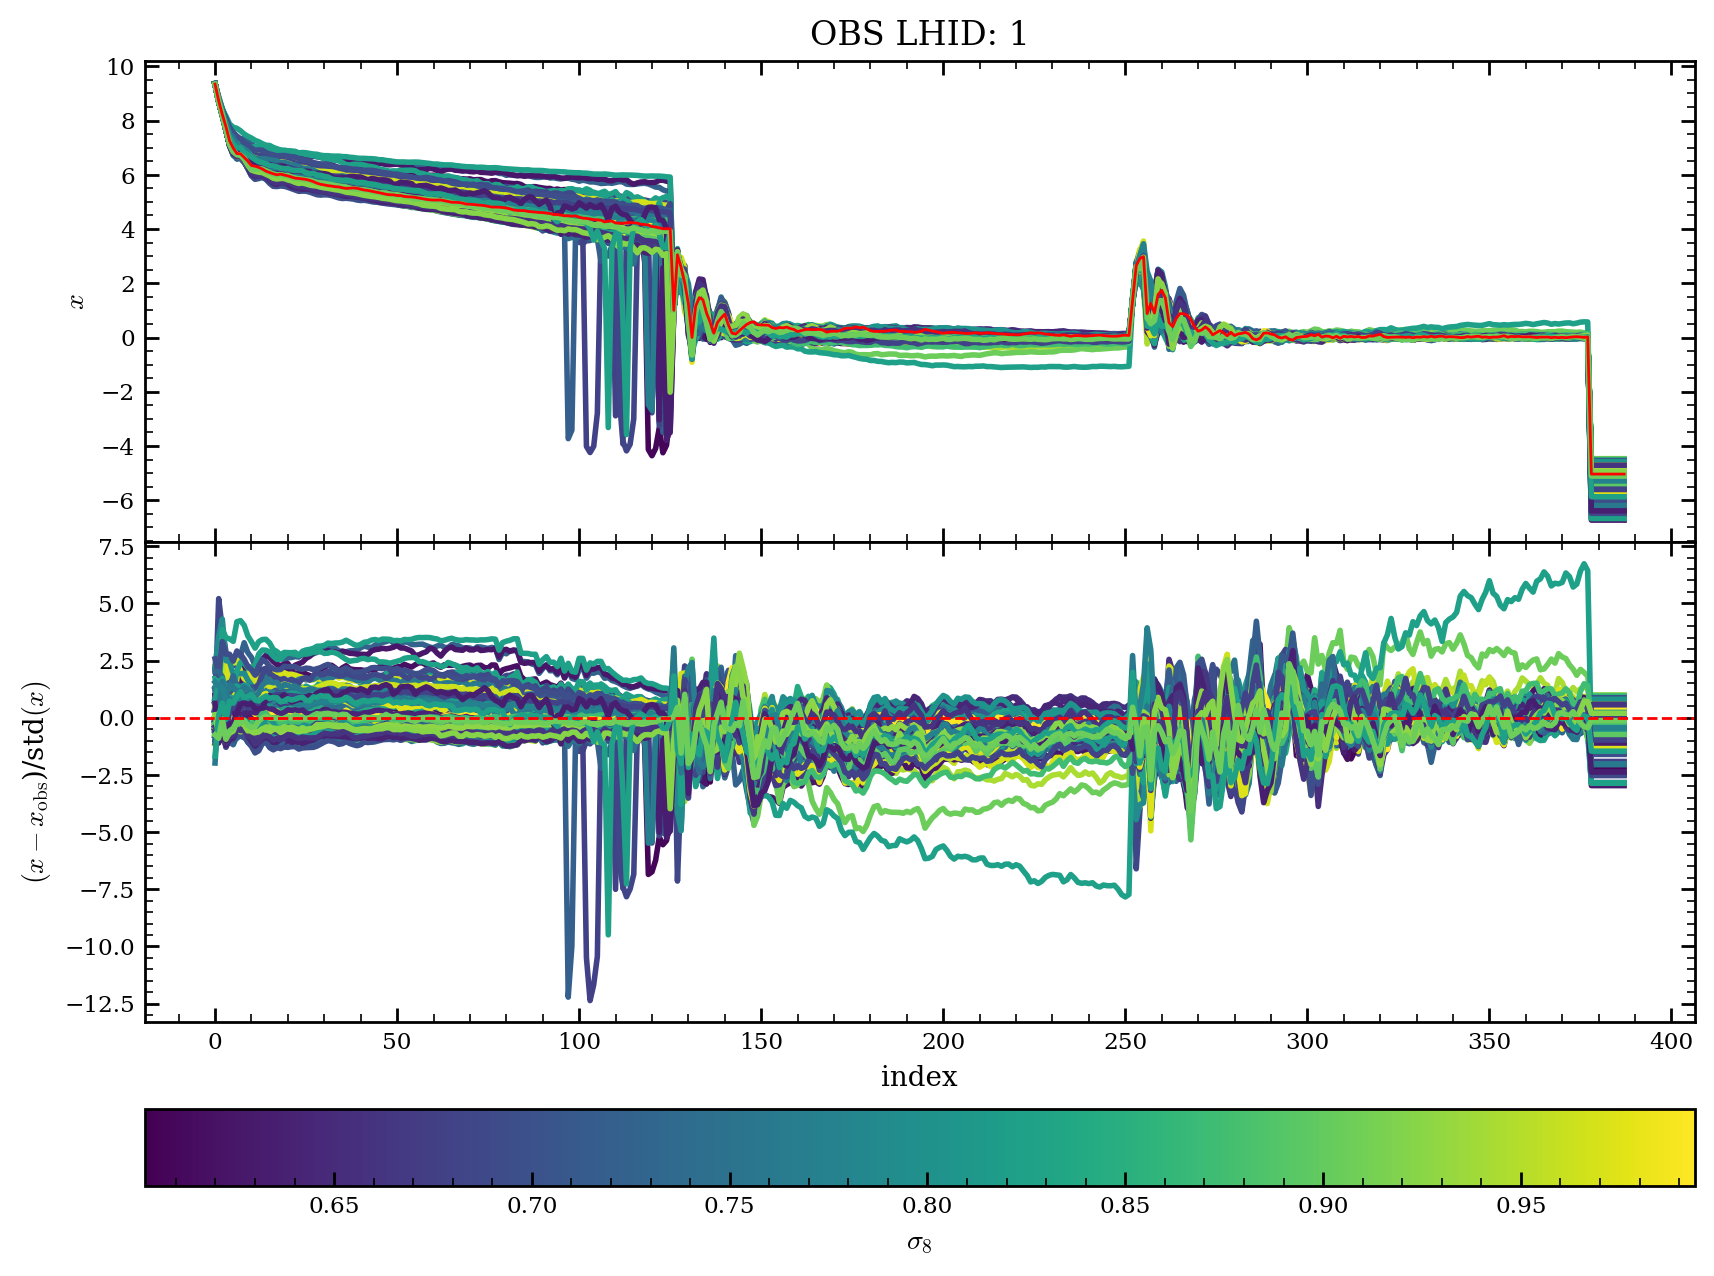

In [121]:
import matplotlib.colors as mcolors

ss = 10
ind = 0

f, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                      gridspec_kw=dict(hspace=0., height_ratios=[1, 1]))

par = ytest[:, 4]
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=par.min(), vmax=par.max())

ax = axs[0]
for i in range(0, len(xtest), ss):
    ax.plot(xtest[i], color=cmap(norm(par[i])))
ax.plot(xobs[ind], 'r-', lw=1)
ax.set(ylabel=r'$x$')
ax.set_title(f'OBS LHID: {xid[ind]}')

ax = axs[1]
for i in range(0, len(xtest), ss):
    ax.plot((xtest[i]-xobs[ind])/np.std(xtest, axis=0),
            color=cmap(norm(par[i])))
ax.axhline(0, c='r', ls='--', lw=1)
ax.set(xlabel='index', ylabel=r'$(x - x_{\rm obs}$)/std$(x)$')

cbar = f.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', pad=0.07)
cbar.set_label(r'$\sigma_8$')

INFO:root:Sampling models with [210, 206, 203, 203, 200, 199, 198, 196, 196, 194] samples each.
Drawing 210 posterior samples: 406it [00:05, 77.27it/s]                         
Drawing 206 posterior samples: 402it [00:04, 97.95it/s]                         
Drawing 203 posterior samples: 381it [00:02, 138.82it/s]                        
Drawing 203 posterior samples: 392it [00:00, 4826.54it/s]             
Drawing 200 posterior samples: 367it [00:04, 77.31it/s]                         
Drawing 199 posterior samples: 375it [00:01, 253.51it/s]                         
Drawing 198 posterior samples: 383it [00:04, 78.00it/s]                         
Drawing 196 posterior samples: 374it [00:04, 76.43it/s]                         
Drawing 196 posterior samples: 368it [00:04, 75.08it/s]                         
Drawing 194 posterior samples: 378it [00:04, 77.17it/s]                         


Text(0.5, 0.98, 'OBS LHID: 1, simbig_lightcone nbar+Pk0+Pk2+Pk4, $k\\in[0.0,0.4]$,')

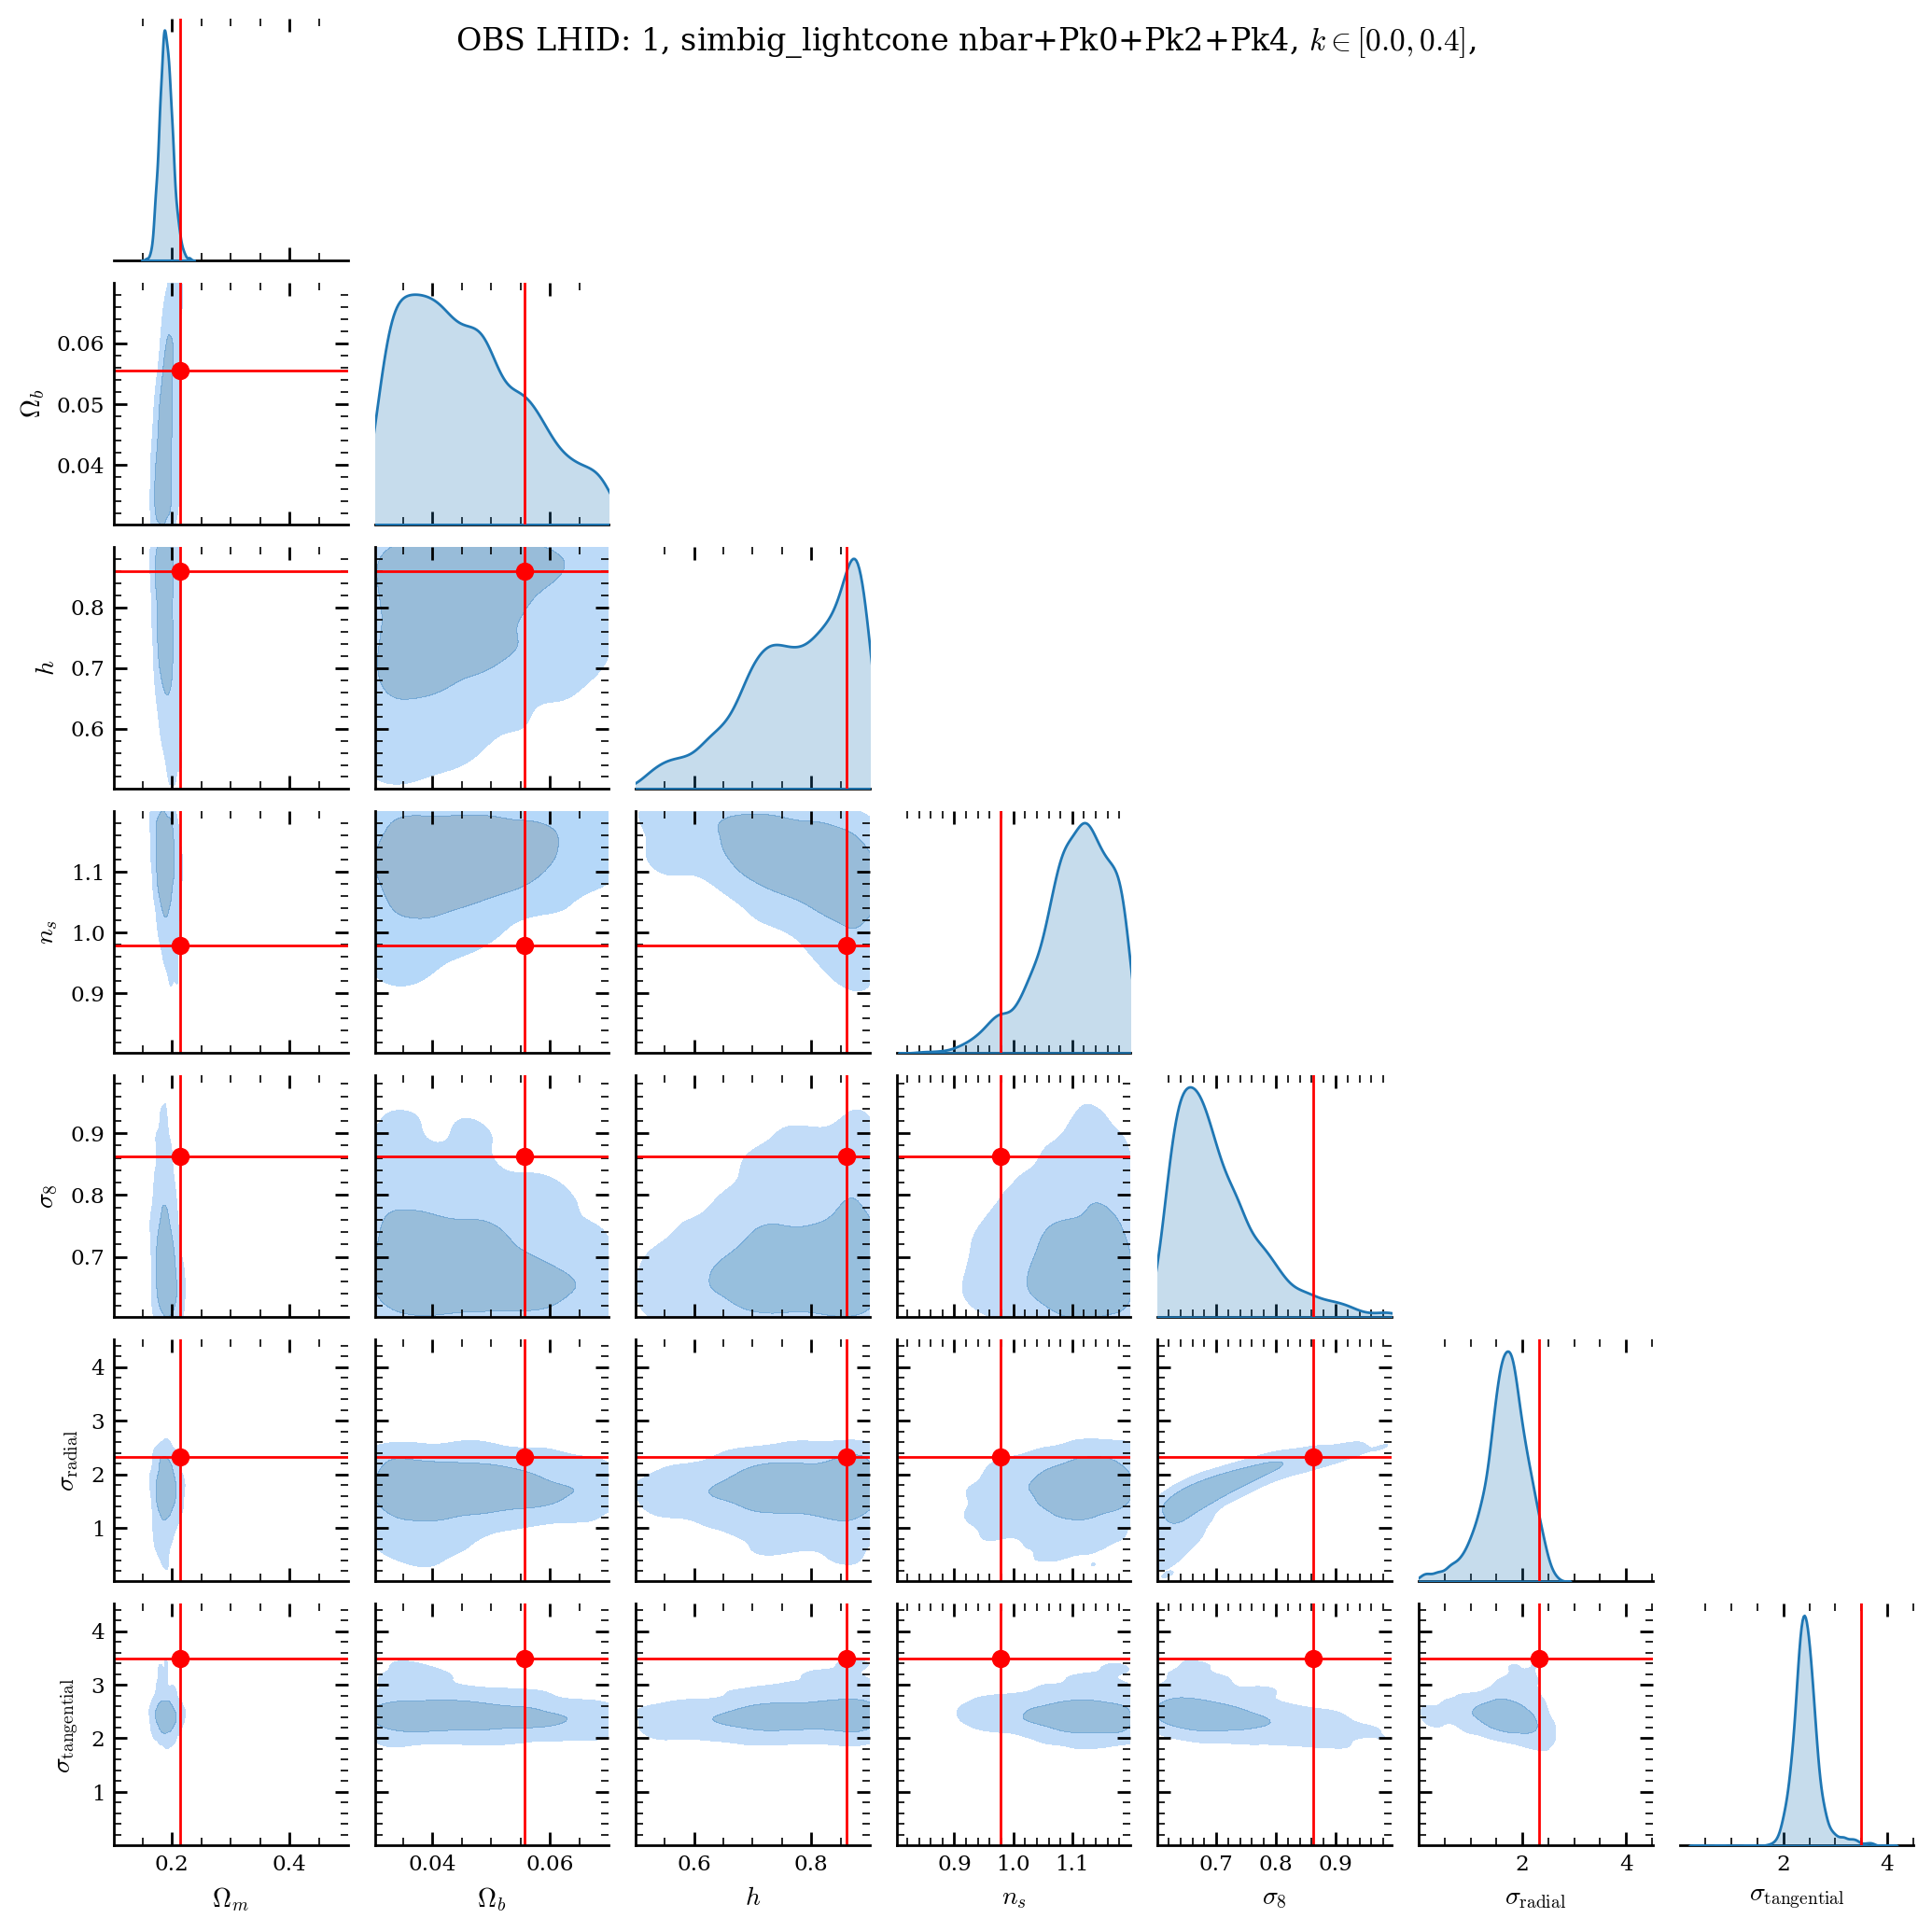

In [122]:
from tools import plot_true_vals, set_boundaries

# Predict on a random test point
ind = 0
samp0 = posterior.sample(x=xobs[ind], shape=(2000,)).to('cpu')
samp0 = pd.DataFrame(samp0, columns=names)


g = sns.pairplot(
    samp0,
    vars=names,
    kind='kde',
    plot_kws={'alpha': 0.5, 'levels': [
        0.05, 0.36, 1], 'fill': True, 'common_norm': False},
    corner=True,
    height=1.5
)
plot_true_vals(g, yobs[ind], color='r', lw=1)
set_boundaries(g, yrange)

g.fig.suptitle(f'OBS LHID: {xid[ind]}, {tracer} ' +
               '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,')

## Predict on a suite of summaries

In [123]:
samps = []
for xin in tqdm(xobs):
    samp = posterior.sample(x=xin, shape=(
        200,), show_progress_bars=False).to('cpu')
    samps.append(samp)
samps = np.array(samps)
trues = np.array(yobs)

100%|██████████| 100/100 [02:17<00:00,  1.37s/it]


Text(0.5, 0.98, 'simbig_lightcone nbar+Pk0+Pk2+Pk4, $k\\in[0.0,0.4]$,')

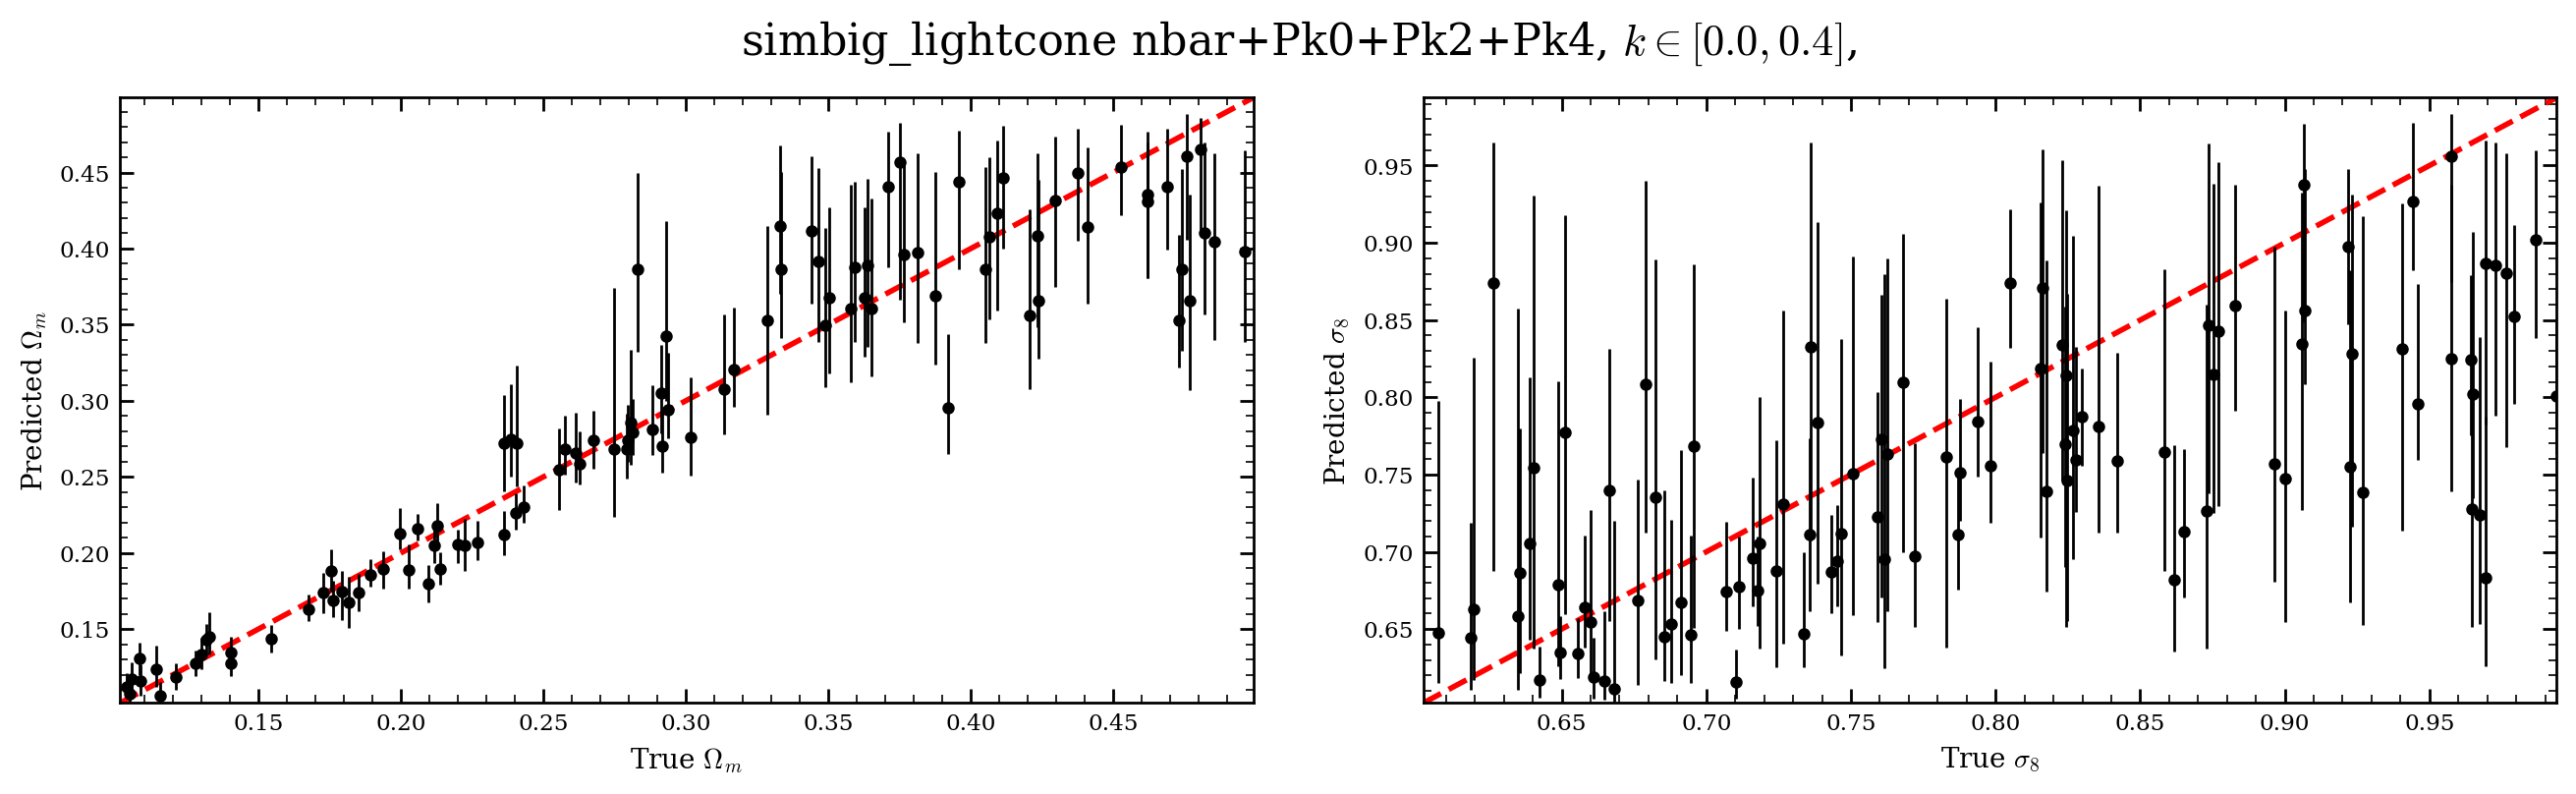

In [124]:
# Plot Om-s8

H, W = 1, 2
f, axs = plt.subplots(H, W, figsize=(8*W, 4*H), gridspec_kw=dict(wspace=0.15))
axs = axs.flatten()

for j, i in enumerate([0, 4]):
    ax = axs[j]
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.set_xlim(yrange[i])
    ax.set_ylim(yrange[i])
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')

    percs = np.percentile(samps[..., i], [50, 16, 84], axis=1)
    ax.plot(trues[:, i], percs[0], '.',
            c='k', markersize=7)
    ax.errorbar(trues[:, i], percs[0], yerr=[percs[0]-percs[1], percs[2]-percs[0]],
                c='k', fmt='none', elinewidth=1)
    # ax.legend()

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,',
    fontsize=16)

Text(0.5, 0.98, 'simbig_lightcone nbar+Pk0+Pk2+Pk4, $k\\in[0.0,0.4]$,')

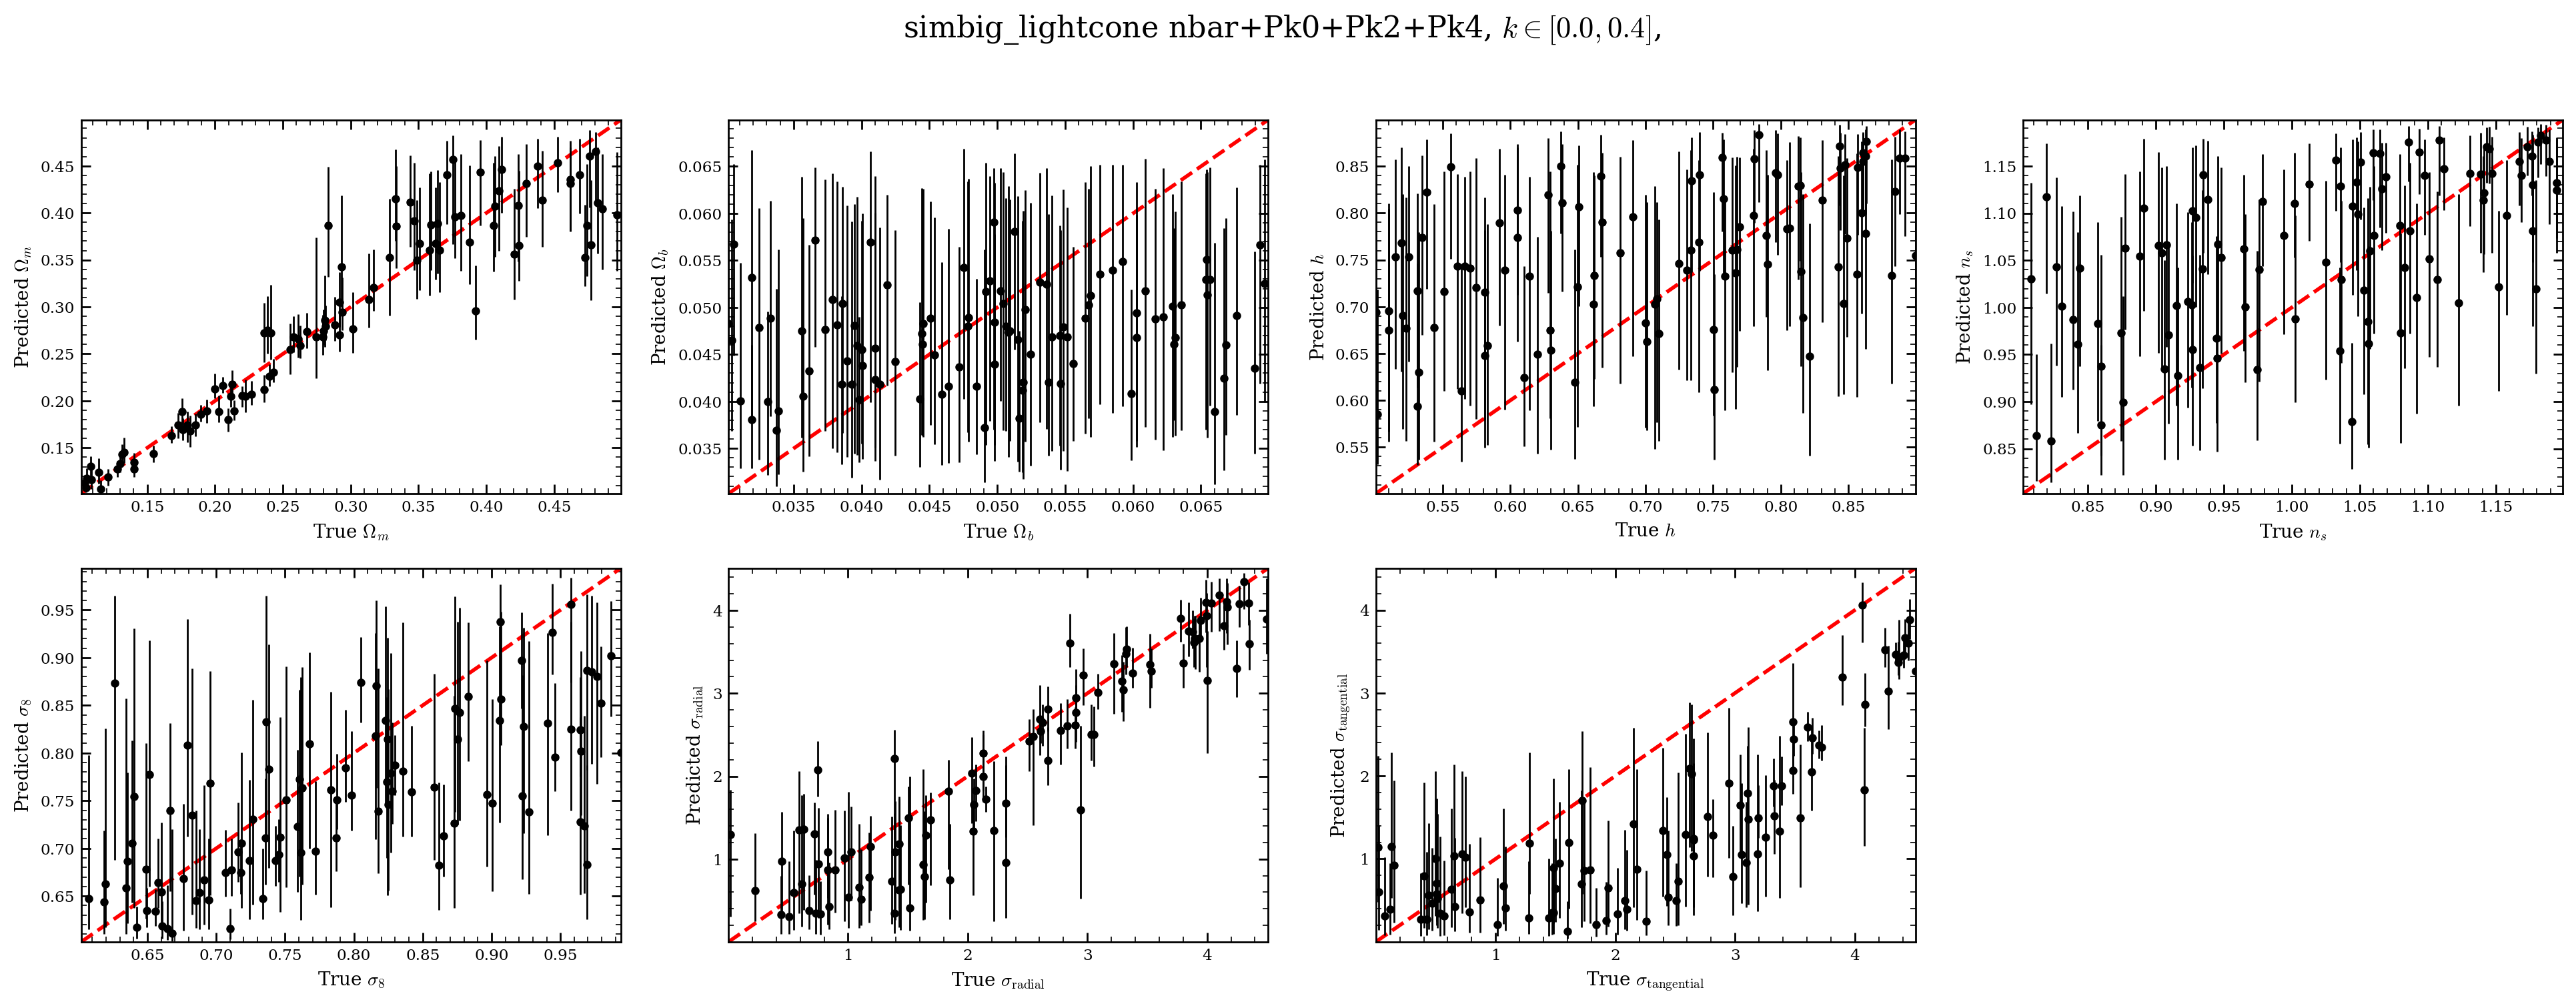

In [125]:
# Plot all parameters
H, W = 2, 4
f, axs = plt.subplots(H, W, figsize=(6*W, 4*H),
                      gridspec_kw=dict(wspace=0.2))
axs = axs.flatten()

for i in range(7):
    j = i
    ax = axs[j]
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.set_xlim(yrange[i])
    ax.set_ylim(yrange[i])
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')

    percs = np.percentile(samps[..., i], [50, 16, 84], axis=1)
    ax.plot(trues[:, i], percs[0], '.',
            c='k', markersize=7)
    ax.errorbar(trues[:, i], percs[0], yerr=[percs[0]-percs[1], percs[2]-percs[0]],
                c='k', fmt='none', elinewidth=1)
    # ax.legend()

for j in range(i+1, H*W):
    ax = axs[j]
    ax.axis('off')

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,',
    fontsize=16)

Text(0.5, 0.98, 'simbig_lightcone nbar+Pk0+Pk2+Pk4, $k\\in[0.0,0.4]$,')

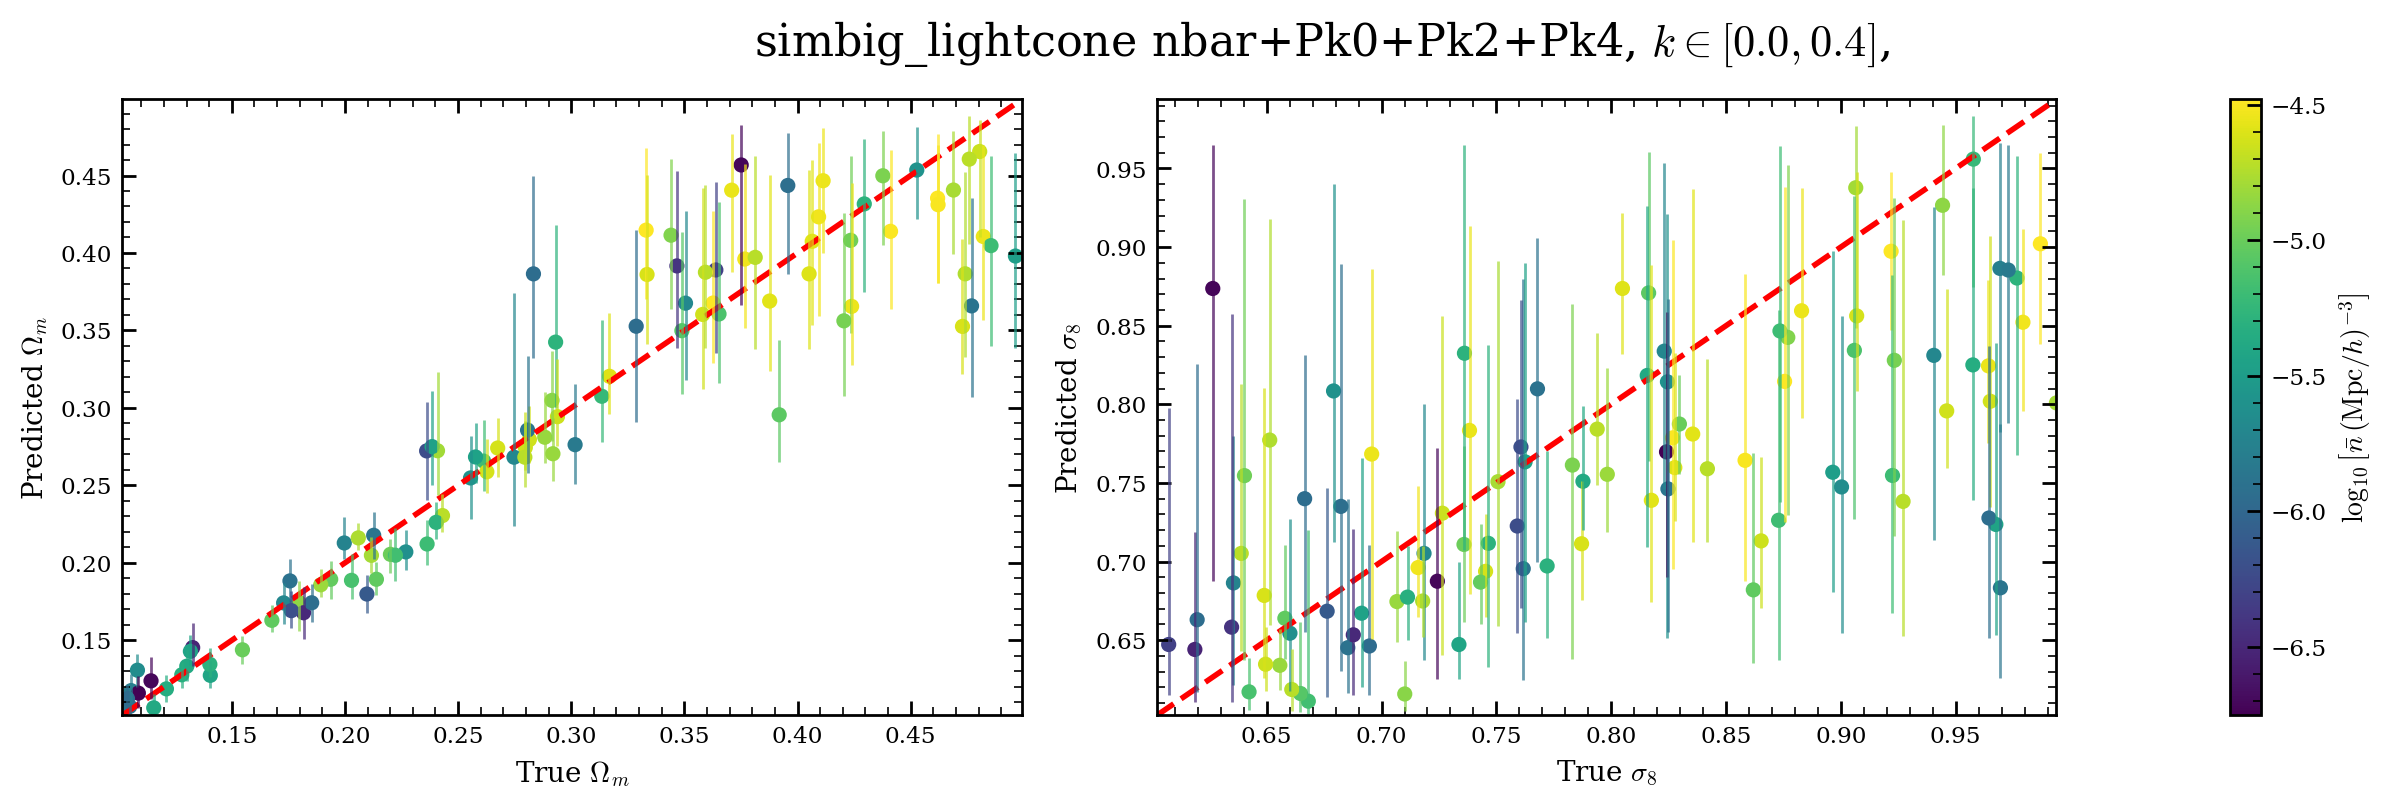

In [126]:
# Plot Om-s8, colored by nbar

H, W = 1, 2
f, axs = plt.subplots(H, W, figsize=(8*W, 4*H), gridspec_kw=dict(wspace=0.15))
axs = axs.flatten()
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=xobs[:, -1].min(), vmax=xobs[:, -1].max())

for j, i in enumerate([0, 4]):
    ax = axs[j]
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.set_xlim(yrange[i])
    ax.set_ylim(yrange[i])
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')
    nbar = xobs[:, -1]

    percs = np.percentile(samps[..., i], [50, 16, 84], axis=1)

    # Plot scatter points
    ax.scatter(trues[:, i], percs[0], c=nbar, cmap=cmap, norm=norm, s=20)

    # Loop to plot each error bar with the correct color
    for k in range(len(trues)):
        color = cmap(norm(nbar[k]))
        ax.errorbar(trues[k, i], percs[0, k],
                    yerr=[[percs[0, k] - percs[1, k]],
                          [percs[2, k] - percs[0, k]]],
                    fmt='none', elinewidth=1, color=color, alpha=0.7)  # Added alpha for better visibility

# Set up the colorbar
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             ax=axs, orientation='vertical', pad=0.07,
             label=r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,',
    fontsize=16)

Text(0.5, 0.98, 'simbig_lightcone nbar+Pk0+Pk2+Pk4, $k\\in[0.0,0.4]$,')

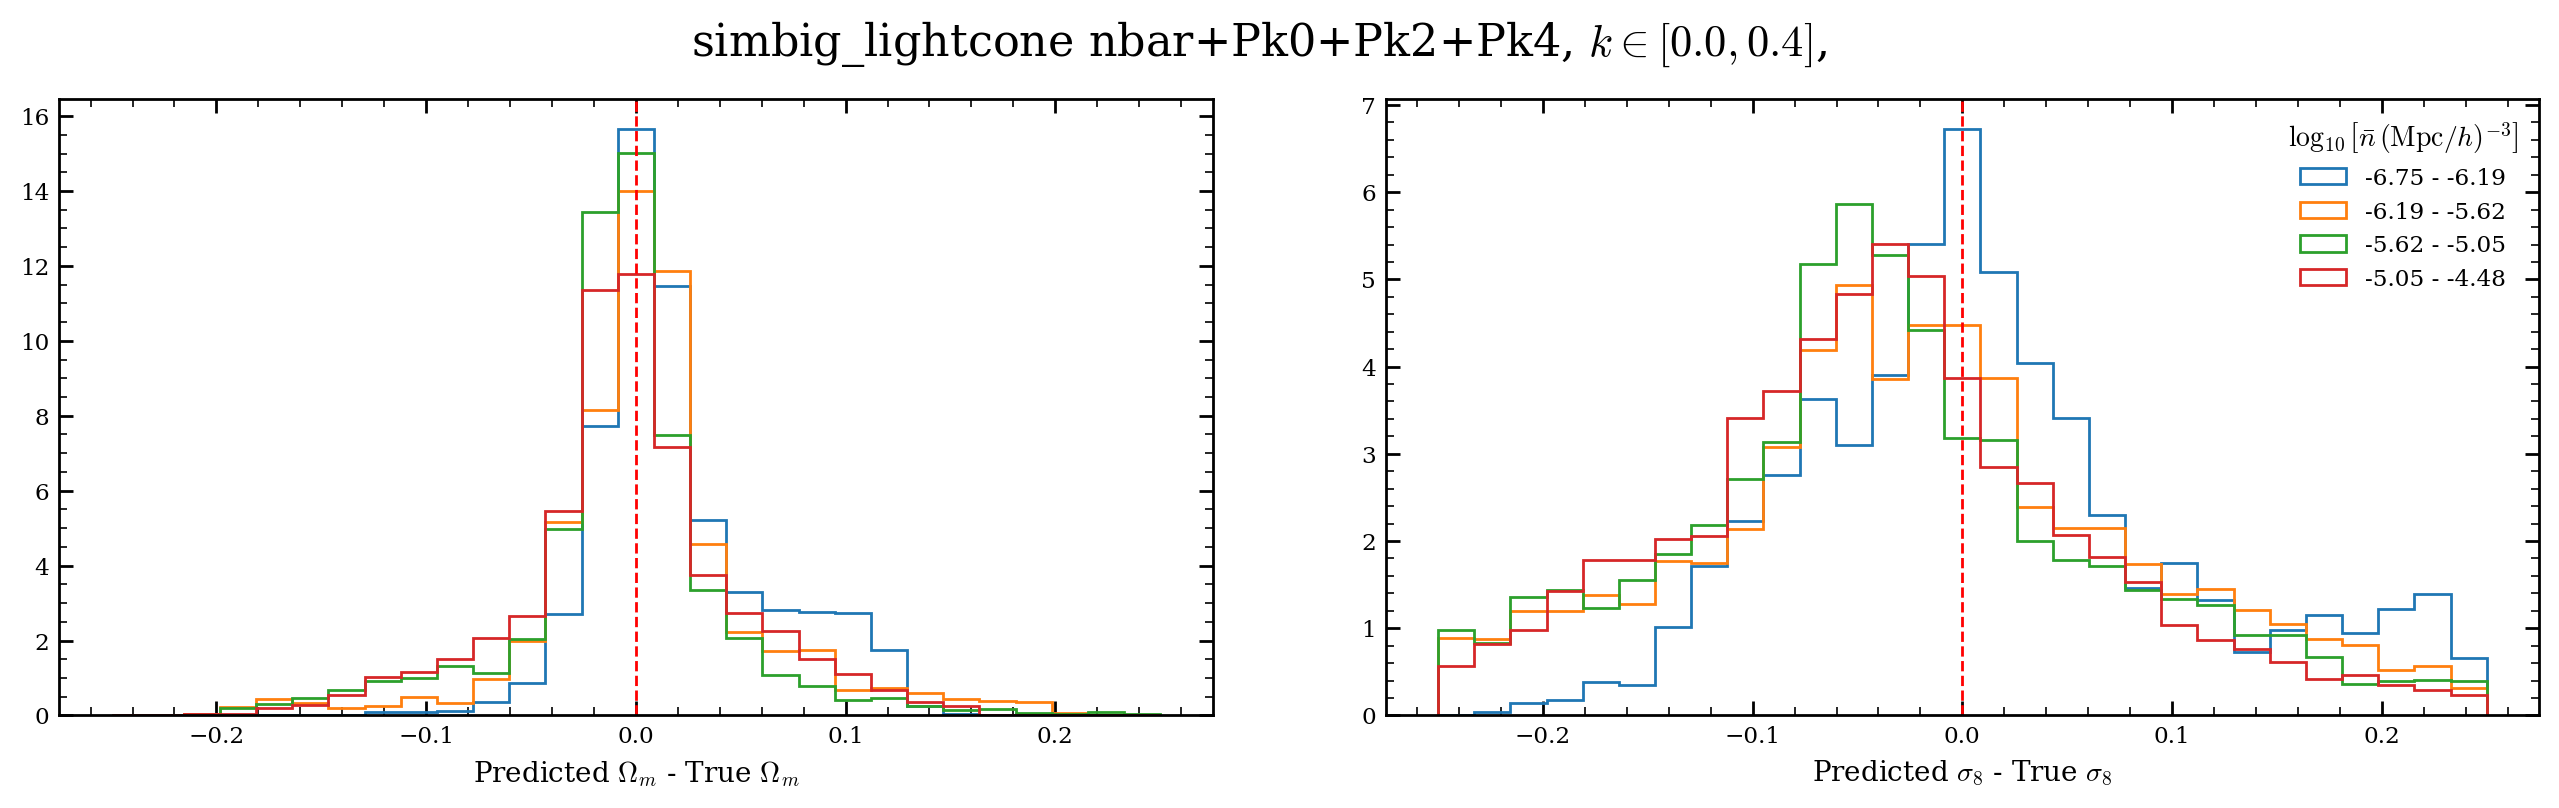

In [127]:
# Plot bias, binned by nbar

H, W = 1, 2
f, axs = plt.subplots(H, W, figsize=(8*W, 4*H), gridspec_kw=dict(wspace=0.15))
axs = axs.flatten()
nbins = np.linspace(
    xobs[:, -1].min(), xobs[:, -1].max(), 5)
ebins = np.linspace(-0.25, 0.25, 30)

for j, i in enumerate([0, 4]):
    ax = axs[j]
    ax.set(xlabel=f'Predicted {names[i]} - True {names[i]}')
    nbar = xobs[:, -1]
    for k in range(len(nbins)-1):
        mask = (nbar >= nbins[k]) & (nbar < nbins[k+1])
        if not np.any(mask):
            continue
        ax.hist((samps[mask, ..., i] - trues[mask, i, None]).flatten(),
                bins=ebins, density=True,
                histtype='step', label=f'{nbins[k]:.2f} - {nbins[k+1]:.2f}')
    ax.axvline(0, c='r', ls='--', lw=1)
ax.legend(title=r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$',)

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,',
    fontsize=16)

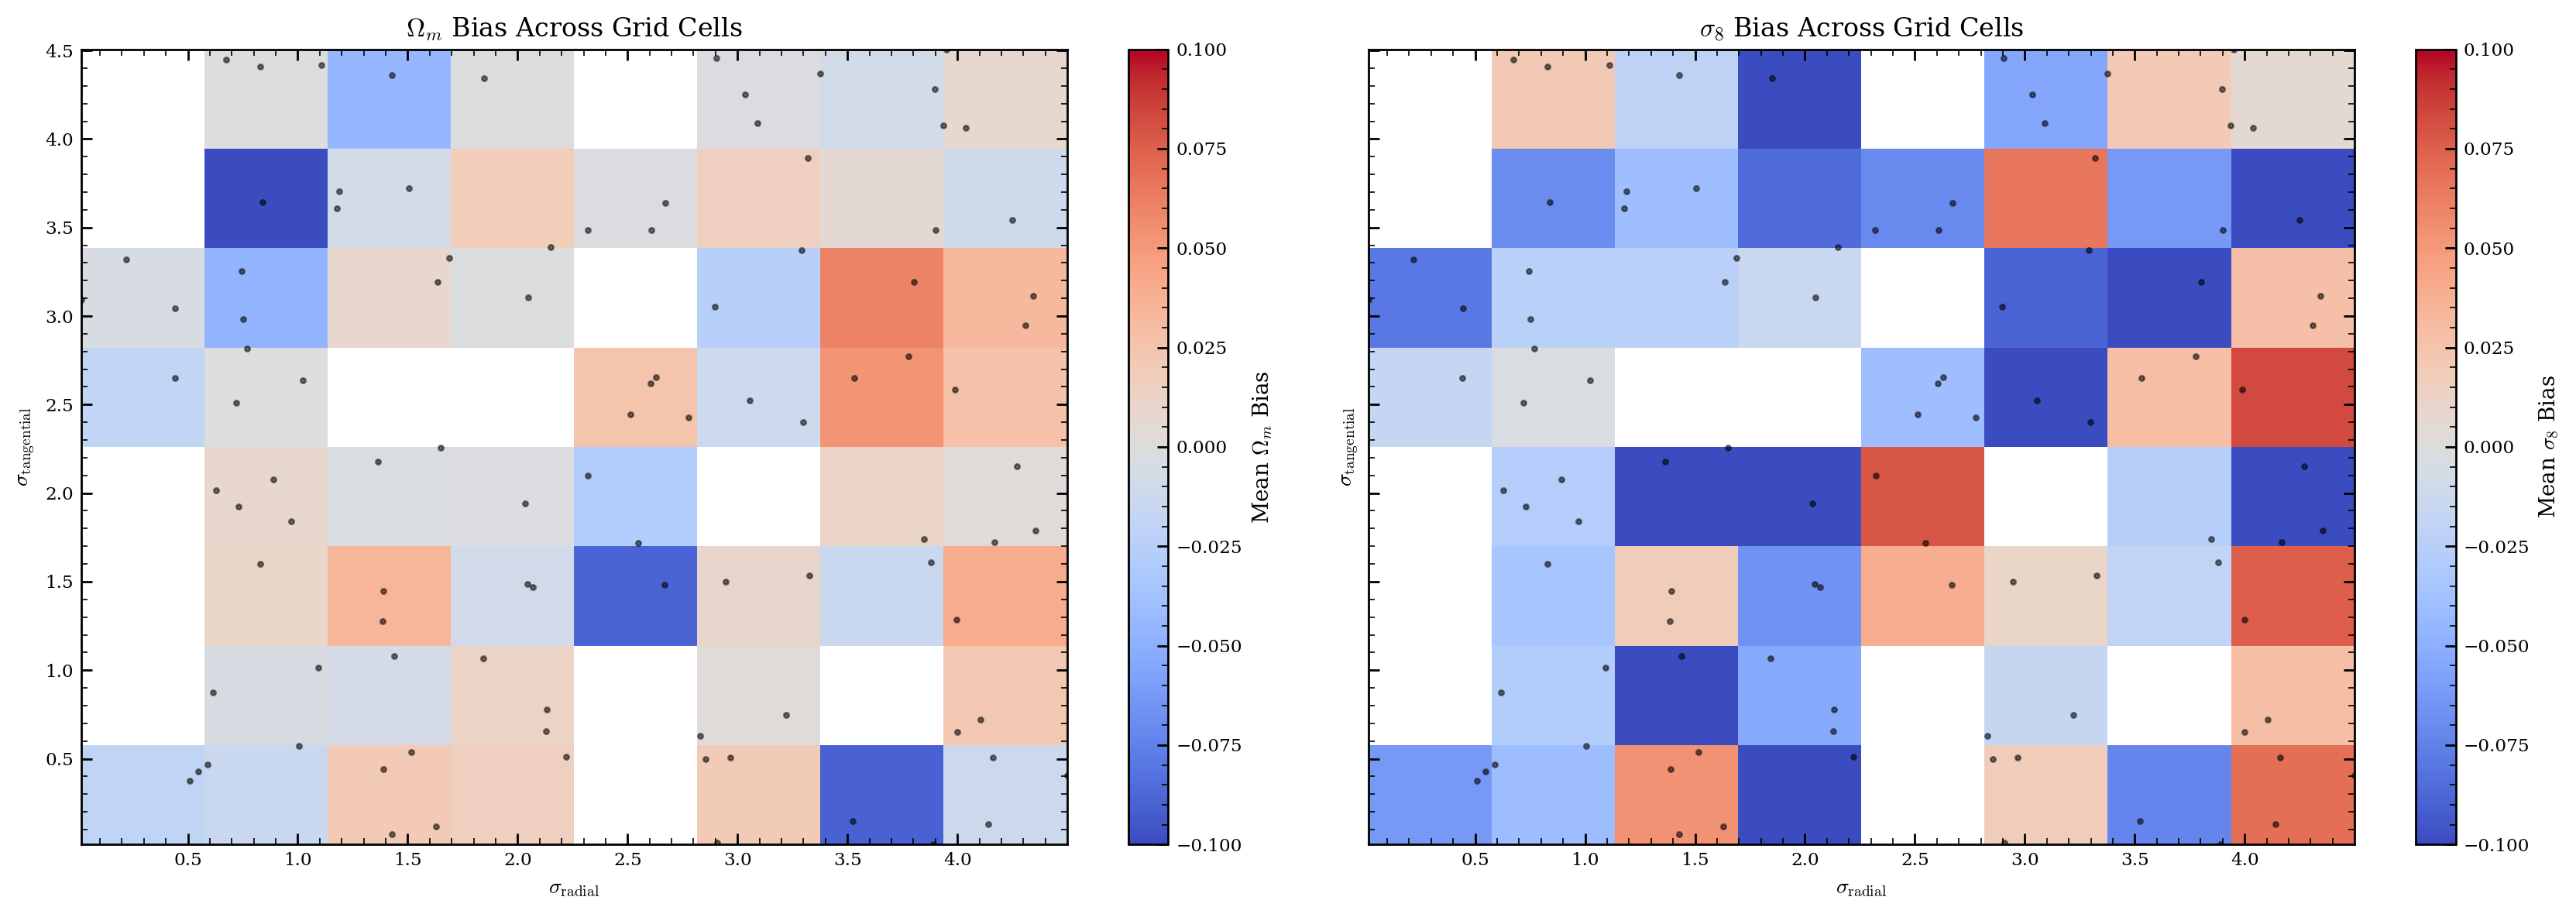

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d


def plot_bias_on_ax(ax, fig, trues, samps, param_index, param_name):
    """Calculates and plots parameter bias on a given subplot axis."""
    sigma_radial = trues[:, 5]
    sigma_transverse = trues[:, 6]

    true_values = trues[:, param_index][:, np.newaxis]
    samps_values = samps[..., param_index]
    mean_bias_per_point = np.mean(samps_values - true_values, axis=1)

    stat, x_edge, y_edge, _ = binned_statistic_2d(
        x=sigma_radial,
        y=sigma_transverse,
        values=mean_bias_per_point,
        statistic='mean',
        bins=8
    )

    mesh = ax.pcolormesh(x_edge, y_edge, stat.T, cmap='coolwarm')
    norm = mpl.colors.Normalize(
        vmin=-np.max(np.abs(stat)), vmax=np.max(np.abs(stat)))
    mesh = ax.pcolormesh(x_edge, y_edge, stat.T, cmap='coolwarm', norm=norm)
    fig.colorbar(mesh, ax=ax, label=f'Mean {param_name} Bias')
    ax.scatter(sigma_radial, sigma_transverse, c='black', s=5, alpha=0.5)

    ax.set_title(f'{param_name} Bias Across Grid Cells')
    ax.set_xlabel(r'$\sigma_{\rm radial}$')
    ax.set_ylabel(r'$\sigma_{\rm tangential}$')


# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6), sharey=True)

# Plot 1: Omega_m (index 0)
plot_bias_on_ax(ax1, fig, trues, samps, 0, r'$\Omega_m$')

# Plot 2: sigma8 (index 4)
plot_bias_on_ax(ax2, fig, trues, samps, 4, r'$\sigma_8$')

plt.tight_layout()
plt.show()

In [92]:
trues.shape, samps.shape

((100, 7), (100, 1000, 7))

In [89]:
bias

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Text(0.5, 0.98, 'simbig_lightcone nbar+Pk0+Pk2+Pk4, $k\\in[0.0,0.4]$,')

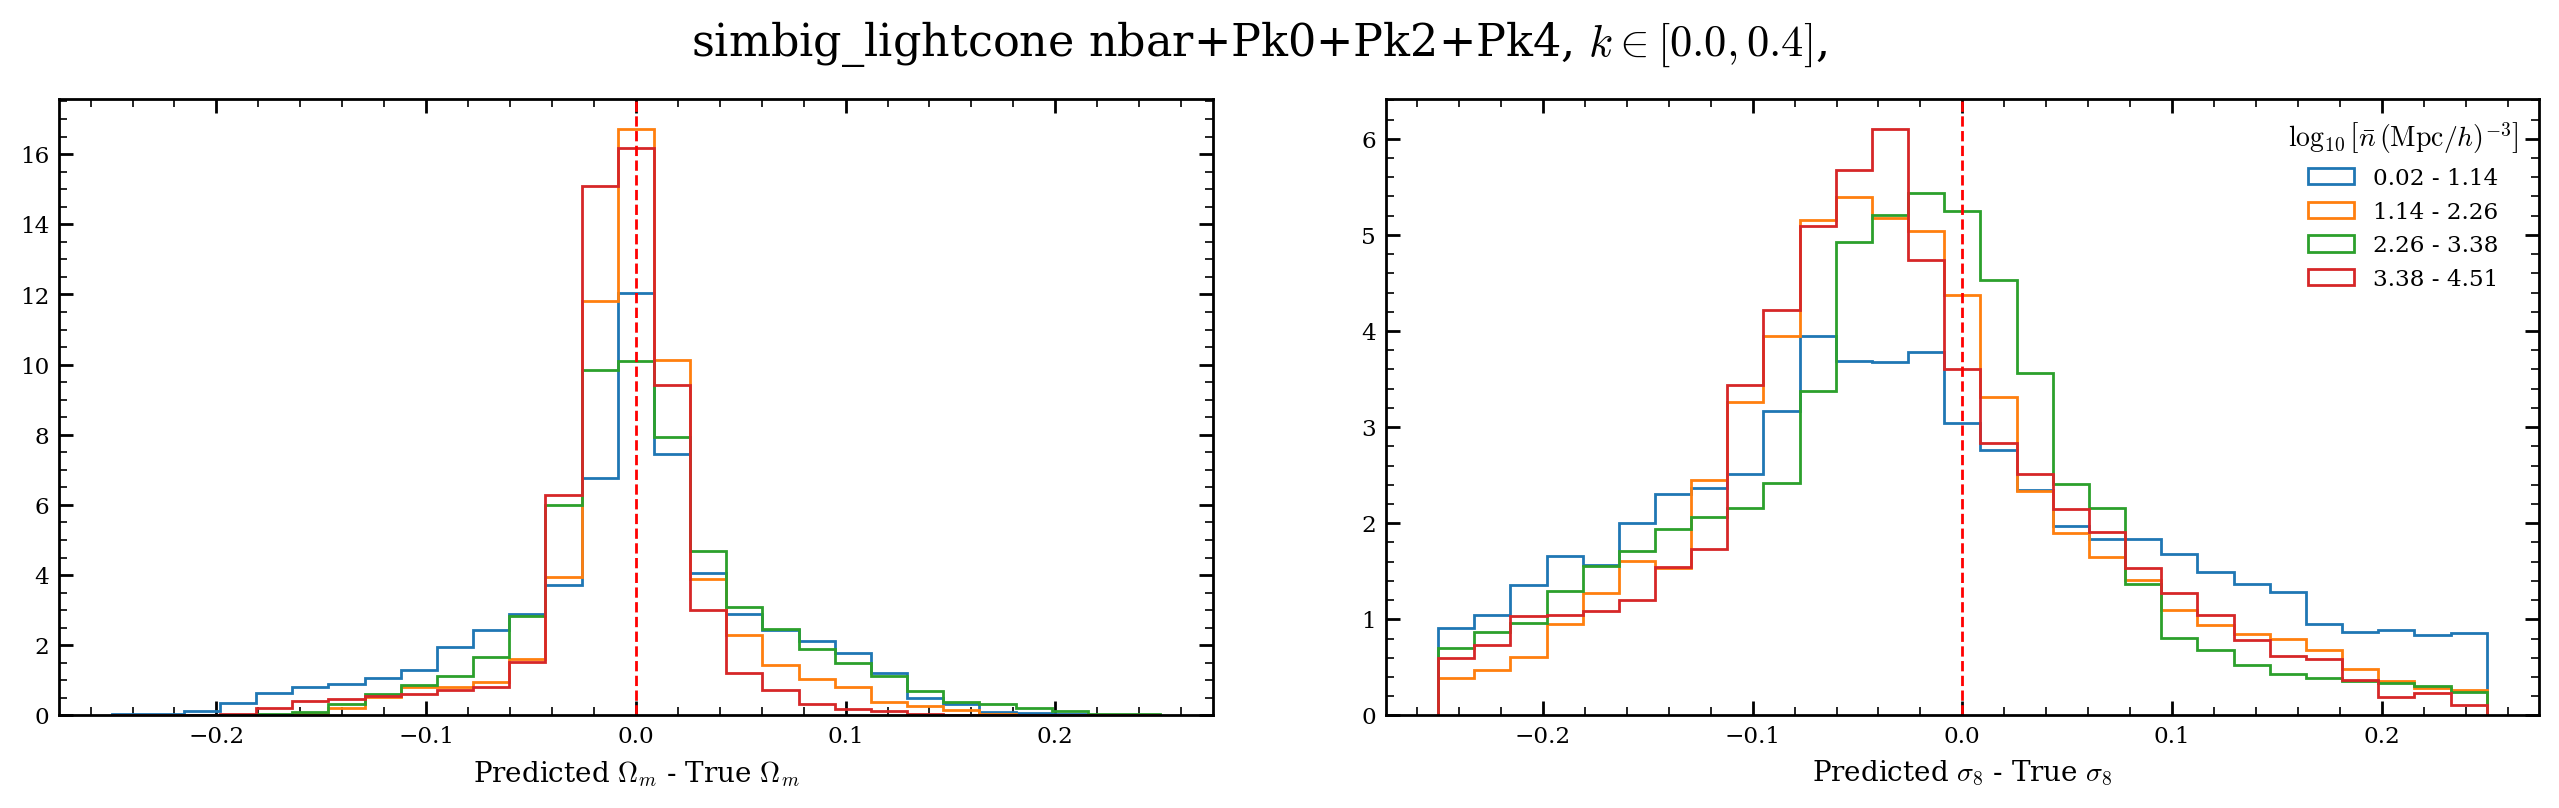

In [ ]:
# Plot bias, binned by nbar

H, W = 1, 2
f, axs = plt.subplots(H, W, figsize=(8*W, 4*H), gridspec_kw=dict(wspace=0.15))
axs = axs.flatten()
nbins = np.linspace(
    trues[:, -1].min(), trues[:, -1].max(), 5)
ebins = np.linspace(-0.25, 0.25, 30)

for j, i in enumerate([0, 4]):
    ax = axs[j]
    ax.set(xlabel=f'Predicted {names[i]} - True {names[i]}')
    nbar = trues[:, -1]
    for k in range(len(nbins)-1):
        mask = (nbar >= nbins[k]) & (nbar < nbins[k+1])
        if not np.any(mask):
            continue
        ax.hist((samps[mask, ..., i] - trues[mask, i, None]).flatten(),
                bins=ebins, density=True,
                histtype='step', label=f'{nbins[k]:.2f} - {nbins[k+1]:.2f}')
    ax.axvline(0, c='r', ls='--', lw=1)
ax.legend(title=r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$',)

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,',
    fontsize=16)